# US Treasury PCA Relative-Value Strategy — full research notebook

A **simple → complex ladder** built on the tested engine package `proj/pca_rv/`:

cumulative-residual → rolling-z signal (Version A reset / Version B rolling-K) →
DV01 engine → three closed-form factor-neutral weight methods (geometric
projection / min-variance hedge / mean-variance alpha) → walk-forward backtest
(+1-day lag, transaction costs, dollar / 10%-vol-targeted PnL) →
**transaction-cost realism** (flat $/contract vs DV01-proportional `dv01_bp`) + a
**trade-to-edge no-trade band** that lets weights drift between trades → Lecture-4
robustness suite → pruned, cached grid-search → top-3 on validation → a **single**
test-period evaluation with validation-seeded residuals.

All heavy logic lives in the unit-tested module; this notebook is narrative and
imports it — **no duplicated logic**. Conventions of record are pinned in
`pca_rv.config` (plan §3.5). The **test set is never touched** until the final
section. Under the realistic `dv01_bp` cost model the cost-sensitivity finding turns
into a **GO** for a trade-to-edge band at **Method 2, τ ≈ 0.75** (§7).

In [1]:
import os, pathlib, sys
# Run from the repo root so relative data/ paths resolve, whether this notebook
# is executed from proj/ (nbconvert default) or the repo root.
here = pathlib.Path.cwd()
if here.name == "proj":
    os.chdir(here.parent)
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "proj"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pca_rv
from pca_rv import config
from pca_rv.data import load_data

data = load_data()
print("sample:", data.changes_bp.index[0].date(), "->", data.changes_bp.index[-1].date())
print("universe:", config.TENORS)
print("splits  train/val/test:", len(data.train_idx), len(data.val_idx), len(data.test_idx))
print("val_end:", data.val_end.date(), "| test_start:", data.test_start.date())

sample: 1977-02-16 -> 2026-05-21
universe: ('US_3M', 'US_6M', 'US_2Y', 'US_5Y', 'US_10Y', 'US_30Y')
splits  train/val/test: 7592 2530 2532
val_end: 2016-09-02 | test_start: 2016-09-05


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# Results export — capture every figure (PNG), table (CSV) and printed message
# into a single self-contained proj/results/ folder + a master report.md.
# Purely additive: this only RECORDS output; the strategy/engine code is untouched.
# Runs AFTER the setup cell's os.chdir, so relative paths resolve from the repo root.
# ════════════════════════════════════════════════════════════════════════════
import datetime as _dt
from pathlib import Path as _Path
from IPython.display import display

RESULTS_DIR = _Path("proj/results")
FIG_DIR = RESULTS_DIR / "figures"
TAB_DIR = RESULTS_DIR / "tables"
for _d in (RESULTS_DIR, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# Ordered, typed buffer of report chunks rendered by flush_report():
#   ("section", title, intro) | ("console", text)
#   ("table", csv_name, caption, md) | ("figure", name, caption)
_REPORT = []


def set_section(title, intro=""):
    """Start a new report section (## header) with an optional explanation paragraph."""
    _REPORT.append(("section", title, intro))
    return title


def say(*args, **kwargs):
    """Drop-in replacement for print(): echo to stdout AND record under the current section."""
    sep = kwargs.get("sep", " ")
    _REPORT.append(("console", sep.join(str(a) for a in args)))
    print(*args, **kwargs)


def df_to_md(obj, floatfmt=None, index=True):
    """Render a DataFrame/Series as a GitHub-flavored-markdown table (no tabulate needed)."""
    frame = (obj.to_frame(name=(obj.name if obj.name is not None else "value"))
             if isinstance(obj, pd.Series) else obj)

    def _esc(x):
        return str(x).replace("|", "\\|").replace("\n", " ")

    def _cell(v):
        if floatfmt is not None and isinstance(v, (float, np.floating)):
            try:
                return format(float(v), floatfmt)
            except (ValueError, TypeError):
                return _esc(v)
        return _esc(v)

    cols = ([_esc(frame.index.name or "")] if index else []) + [_esc(c) for c in frame.columns]
    lines = ["| " + " | ".join(cols) + " |",
             "| " + " | ".join("---" for _ in cols) + " |"]
    for idx, row in frame.iterrows():
        cells = ([str(idx)] if index else []) + [_cell(v) for v in row.tolist()]
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines)


def save_fig(name, fig=None, caption=""):
    """Save the current (or given) matplotlib figure to proj/results/figures/<name>."""
    (fig if fig is not None else plt.gcf()).savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")
    _REPORT.append(("figure", name, caption))
    return FIG_DIR / name


def save_table(df, name, caption="", floatfmt=None, index=True, show=True):
    """Write proj/results/tables/<name>.csv, record a markdown table, and (by default) display it."""
    csv_name = name if name.endswith(".csv") else name + ".csv"
    df.to_csv(TAB_DIR / csv_name, index=index)
    _REPORT.append(("table", csv_name, caption, df_to_md(df, floatfmt=floatfmt, index=index)))
    if show:
        display(df)
    return df


def _slug(title):
    return "".join(c for c in title.lower() if c.isalnum() or c in " -").strip().replace(" ", "-")


def flush_report(title="US PCA Relative-Value Strategy — results report"):
    """Assemble the ordered buffer into proj/results/report.md (figures + tables + console)."""
    out = [f"# {title}", "",
           f"_Auto-generated {_dt.datetime.now():%Y-%m-%d %H:%M} from "
           "`proj/us_pca_rv_strategy_full.ipynb`. Figures live in `figures/`, raw CSVs in `tables/`._",
           ""]
    sections = [c[1] for c in _REPORT if c[0] == "section"]
    if sections:
        out += ["## Contents", ""]
        out += [f"- [{t}](#{_slug(t)})" for t in sections]
        out += [""]

    pending = []

    def _flush_console():
        if pending:
            out.extend(["```text", *pending, "```", ""])
            pending.clear()

    for chunk in _REPORT:
        if chunk[0] == "console":
            pending.append(chunk[1])
            continue
        _flush_console()
        if chunk[0] == "section":
            _, t, intro = chunk
            out += [f"## {t}", ""]
            if intro:
                out += [intro, ""]
        elif chunk[0] == "figure":
            _, name, caption = chunk
            if caption:
                out += [f"**{caption}**", ""]
            out += [f"![{caption or name}](figures/{name})", ""]
        elif chunk[0] == "table":
            _, csv_name, caption, md = chunk
            if caption:
                out += [f"**{caption}**", ""]
            out += [md, "", f"_Source data: [`tables/{csv_name}`](tables/{csv_name})_", ""]
    _flush_console()
    path = RESULTS_DIR / "report.md"
    path.write_text("\n".join(out), encoding="utf-8")
    return path


set_section(
    "Setup & data universe",
    intro=(f"US Treasury par-yield panel **{data.changes_bp.index[0].date()} → "
           f"{data.changes_bp.index[-1].date()}**. Universe: {', '.join(config.TENORS)}. "
           f"Chronological split train / val / test = {len(data.train_idx)} / {len(data.val_idx)} / "
           f"{len(data.test_idx)} (validation ends {data.val_end.date()}, test starts "
           f"{data.test_start.date()}). Every figure, table and printed message below is exported "
           "to `proj/results/`."),
)

'Setup & data universe'

## 1. Data / EDA recap

Constant-maturity US par yields (percent). The engine works in **bp-change
space**: `changes_bp = levels.diff() * 100`. Universe excludes 3Y (data gap).
60/20/20 chronological split; the test block is held out until §12.

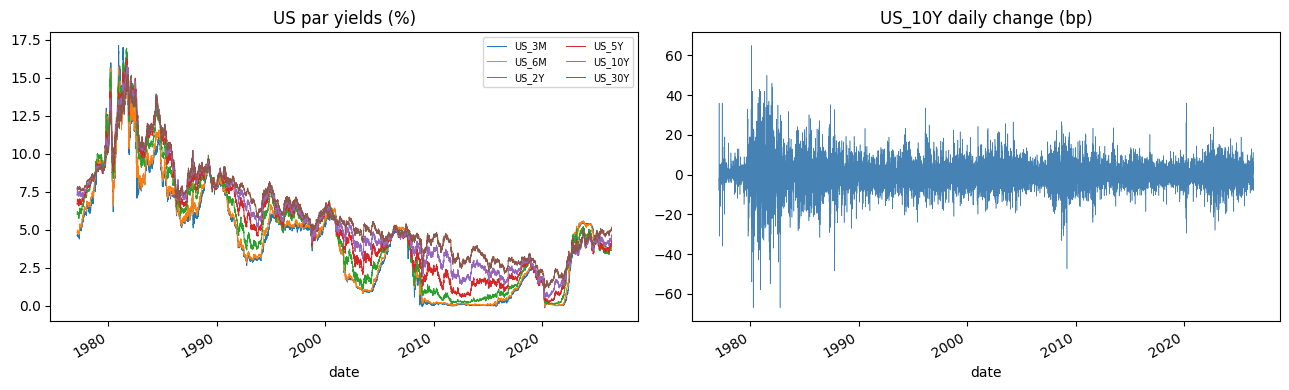

,US_3M,US_6M,US_2Y,US_5Y,US_10Y,US_30Y
count,12654.00,12654.00,12654.00,12654.00,12654.00,12654.00
mean,-0.01,-0.01,-0.02,-0.02,-0.02,-0.02
std,8.95,8.07,8.23,7.84,7.24,6.52
min,-127.00,-110.00,-118.00,-108.00,-67.00,-56.00
25%,-1.53,-1.53,-2.83,-3.60,-3.67,-3.30
50%,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.72,1.80,2.99,3.52,3.60,3.20
max,134.00,117.00,146.00,72.00,65.00,50.00


,US_3M,US_6M,US_2Y,US_5Y,US_10Y,US_30Y
count,12654.00,12654.00,12654.00,12654.00,12654.00,12654.00
mean,-0.01,-0.01,-0.02,-0.02,-0.02,-0.02
std,8.95,8.07,8.23,7.84,7.24,6.52
min,-127.00,-110.00,-118.00,-108.00,-67.00,-56.00
25%,-1.53,-1.53,-2.83,-3.60,-3.67,-3.30
50%,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.72,1.80,2.99,3.52,3.60,3.20
max,134.00,117.00,146.00,72.00,65.00,50.00


In [3]:
set_section("§1 Data / EDA recap",
            intro="US par-yield levels across the curve and the daily-change distribution "
                  "(basis points) that the PCA relative-value engine trades on.")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
data.levels_pct.plot(ax=ax[0], lw=0.7); ax[0].set_title("US par yields (%)"); ax[0].legend(fontsize=7, ncol=2)
data.changes_bp["US_10Y"].plot(ax=ax[1], lw=0.4, color="steelblue")
ax[1].set_title("US_10Y daily change (bp)"); plt.tight_layout()
save_fig("fig01_eda_yields_and_10y_changes.png", fig,
         caption="US par yields (%) and US_10Y daily change (bp)")
plt.show()
save_table(data.changes_bp.describe().round(2), "tbl01_changes_bp_describe",
           caption="Daily yield-change summary statistics (bp)")

## 2. DV01 engine

Par-yield DV01 in **$ per $100 face per 1bp** with three instrument branches
(sub-1Y bill / 1Y zero / coupon par), zero-yield guard. Worked-example checks
match the supplementary derivation.

In [4]:
from pca_rv.dv01 import build_dv01_matrix, dv01_per_100, persist_dv01
set_section("§2 DV01 engine",
            intro="Bond DV01 ($ per $100 face per 1bp), checked against documented worked examples, "
                  "then the latest cross-sectional DV01 snapshot used to turn yield-space books into "
                  "tradable contracts.")
dv01 = persist_dv01(data.levels_decimal_full)  # also writes data/bond/yields/dv01_per100.csv
say("worked examples (per $100 face):")
say(f"  10Y @4.47% coupon : {dv01_per_100(0.0447,10):.5f}  (doc ~0.0800)")
say(f"  1Y  @4.9%  zero   : {dv01_per_100(0.049,1.0):.5f}  (doc ~0.0093)")
say(f"  3M  @5.0%  bill   : {dv01_per_100(0.05,0.25):.6f} (doc ~0.002439)")
save_table(dv01[["US_3M","US_12M","US_2Y","US_5Y","US_10Y","US_30Y"]].dropna().iloc[-1].round(5)
           .to_frame("DV01 ($/$100/bp)"),
           "tbl02_dv01_latest", caption="Latest-date DV01 by tenor ($ per $100 face per 1bp)")

worked examples (per $100 face):
  10Y @4.47% coupon : 0.07993  (doc ~0.0800)
  1Y  @4.9%  zero   : 0.00930  (doc ~0.0093)
  3M  @5.0%  bill   : 0.002439 (doc ~0.002439)


,DV01 ($/$100/bp)
US_3M,0.00245
US_12M,0.00945
US_2Y,0.01902
US_5Y,0.04464
US_10Y,0.07958
US_30Y,0.15290


,DV01 ($/$100/bp)
US_3M,0.00245
US_12M,0.00945
US_2Y,0.01902
US_5Y,0.04464
US_10Y,0.07958
US_30Y,0.15290


## 3. Residual + signal engine (Version A vs B)

Forward, per-block-frozen PCA (3 PCs) gives **factor residuals**; cumulating them
gives the mean-reverting signal. **Version A** resets the cumulative residual to
zero at each PCA refit; **Version B** is a trailing rolling-K sum. A strictly
causal rolling z-score turns either into the trade signal `s`.

max |resid . V^T| on a block: 1.948099379753295e-14


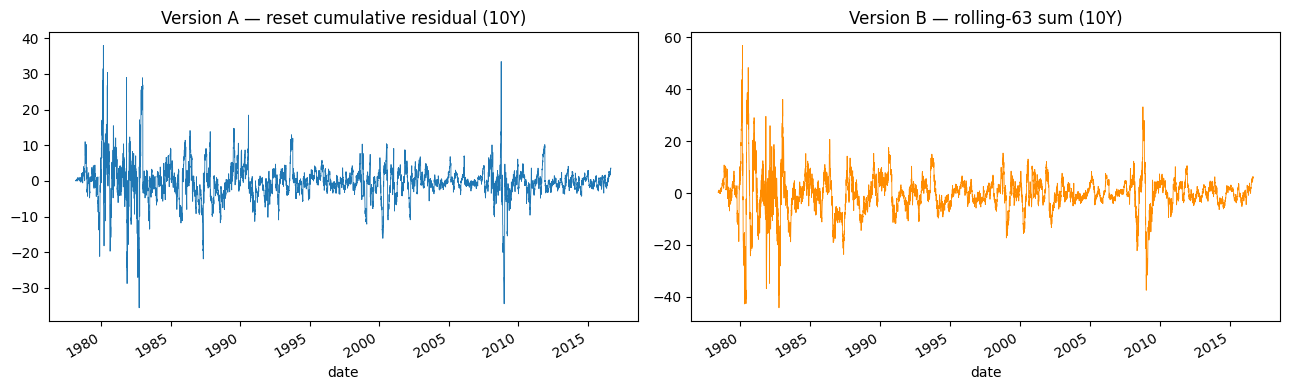

causal half-life (days), latest estimate:


{'US_3M': 179.7, 'US_6M': 201.4, 'US_2Y': 100.1, 'US_5Y': 140.5, 'US_10Y': 198.9, 'US_30Y': 299.1}


In [5]:
from pca_rv.residual import forward_residuals_cov
from pca_rv.signal import cumulative_residual, rolling_zscore, causal_half_life
set_section("§3 Residual + signal engine",
            intro="Forward-looking PCA residuals (orthogonal to the frozen loadings within each "
                  "block) and the two signal constructions: Version A (reset cumulative residual) "
                  "and Version B (rolling-K sum).")

ch = data.changes_bp.loc[:data.val_end]          # train+val only (no test leak)
out = forward_residuals_cov(ch, window=252, block=63, cov_method="ledoit_wolf")
resid = out["resid_svd"]
# orthogonality of residuals to the frozen loadings (per block)
d0 = out["refit_dates"][5]; V0 = out["loadings_panel"][d0]
seg = resid.loc[d0:].iloc[:63].dropna()
say("max |resid . V^T| on a block:", float(np.max(np.abs(seg.to_numpy() @ V0.T))))

zA = cumulative_residual(resid, "A", out["refit_dates"])
zB = cumulative_residual(resid, "B", out["refit_dates"], K=63)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
zA["US_10Y"].plot(ax=ax[0], lw=0.6); ax[0].set_title("Version A — reset cumulative residual (10Y)")
zB["US_10Y"].plot(ax=ax[1], lw=0.6, color="darkorange"); ax[1].set_title("Version B — rolling-63 sum (10Y)")
plt.tight_layout()
save_fig("fig03_residual_signal_A_vs_B.png", fig,
         caption="Version A reset cumulative residual vs Version B rolling-63 sum (US_10Y)")
plt.show()
say("causal half-life (days), latest estimate:")
say(causal_half_life(resid, out["refit_dates"]).dropna().iloc[-1].round(1).to_dict())

## 4. Method 1 — geometric projection, single-tenor yield-space baseline

`g = -s_{t,m} M e_m` (L1-normalized), traded via the entry/exit state machine on
the most-dislocated tenor. PnL is the canonical yield-space chain `Σ g·Δy` with a
+1-day execution lag — no DV01 multiplier. This is the simplest rung.

Method 1 baseline: IR 0.505 | MDD 61.04 | turnover 0.0028
  neutrality max||Vg|| 6.3e-15 | rho_m_min 0.0035


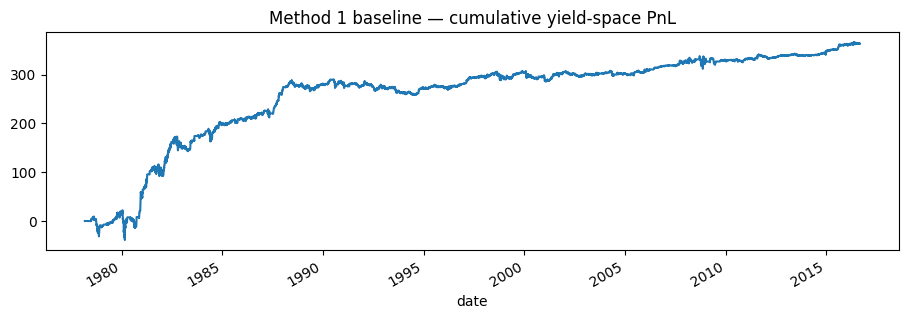

In [6]:
from pca_rv.config import StrategyConfig
from pca_rv.backtest import run_backtest
set_section("§4 Method 1 baseline",
            intro="Single-tenor yield-space Method-1 strategy: information ratio, max drawdown, "
                  "turnover and factor-neutrality diagnostics, with cumulative yield-space PnL.")

cfg1 = StrategyConfig("A", z_window=63, method=1, covariance="sample",
                      pca_window=252, refit=63, cost_per_contract_usd=0.0,
                      entry=2.0, exit=0.0)
r1 = run_backtest(cfg1, data, changes=ch)
say(f"Method 1 baseline: IR {r1.ir:.3f} | MDD {r1.mdd:.2f} | turnover {r1.turnover:.4f}")
say(f"  neutrality max||Vg|| {r1.diagnostics['max_neutrality_resid']:.1e} | rho_m_min {r1.diagnostics['rho_m_min']:.4f}")
r1.pnl_yield.cumsum().plot(figsize=(11,3.2), title="Method 1 baseline — cumulative yield-space PnL")
save_fig("fig04_method1_cumulative_pnl.png", caption="Method 1 baseline — cumulative yield-space PnL")
plt.show()

## 5. Methods 2 & 3 + covariance variants

**Method 2** (min-variance hedge): closed-form KKT that pins the *single* most-dislocated
tenor to `a_t=-s_{t,m}` and min-var hedges the rest to factor-neutrality — so only one
tenor's z-score is an active view. **Method 2-all** generalizes this to pin *every*
independently-targetable dislocation at once: the factor-neutral subspace has dimension
`p - rank(V) = 6 - 3 = 3`, so it pins the **top 3** most-dislocated tenors
(`e_iᵀg = -s_{t,i}`); pinning more would over-determine the KKT system. **Method 3**
(mean-variance) instead uses all six tenors *softly* via the alpha `α=-s·σ` traded off
against variance (γ a single calibrated scalar). Σ is swappable (sample / EWMA /
Ledoit-Wolf). The table compares gross IR across all three — note that pinning *more*
tenors (2 → 2-all) is **not** automatically better.

In [7]:
from pca_rv.backtest import calibrate_gamma
set_section("§5 Methods 2 & 3 + covariance variants",
            intro="Method 2 (min-variance hedge; 'single' pins argmax|s|, 'all' pins all "
                  "dislocations) vs Method 3 (mean-variance, six tenors soft) across three "
                  "covariance estimators (sample, EWMA, Ledoit-Wolf), with neutrality and "
                  "conditioning diagnostics.")
say("calibrated GAMMA (config):", config.GAMMA)
# "2" pins only argmax|s| (one active view); "2-all" pins all independently-targetable
# dislocations (top p-k = 3 tenors); "3" uses all six tenors softly via mean-variance.
variants = [("2", dict(method=2, method2_mode="single")),
            ("2-all", dict(method=2, method2_mode="all")),
            ("3", dict(method=3))]
rows = []
for label, kw in variants:
    for cov in ("sample", "ewma", "lw"):
        c = StrategyConfig("A", z_window=63, covariance=cov, pca_window=252, refit=63,
                           cost_per_contract_usd=0.0, **kw)
        r = run_backtest(c, data, changes=ch)
        rows.append({"method": label, "cov": cov, "IR": round(r.ir, 3),
                     "neutral": f"{r.diagnostics['max_neutrality_resid']:.1e}",
                     "sigma_cond": round(r.diagnostics['sigma_cov_cond'], 1),
                     "kkt_cond": round(r.diagnostics['kkt_cond'], 1)})
save_table(pd.DataFrame(rows), "tbl05_methods_cov_grid", index=False,
           caption="Methods 2/3 × covariance estimator — IR, neutrality residual, conditioning")

calibrated GAMMA (config): 3171.159


,method,cov,IR,neutral,sigma_cond,kkt_cond
0,2,sample,0.871,9.4e-14,887.0,111.6
1,2,ewma,0.719,1.3e-13,1120.1,87.1
2,2,lw,0.790,2.0e-13,290.8,84.9
3,2-all,sample,-0.066,1.8e-12,887.0,111.6
4,2-all,ewma,0.053,1.2e-10,1120.1,87.1
5,2-all,lw,-0.066,1.8e-12,290.8,84.9
6,3,sample,1.249,3.5e-18,887.0,111.6
7,3,ewma,1.263,5.2e-18,1120.1,87.1
8,3,lw,1.318,1.7e-18,290.8,84.9


,method,cov,IR,neutral,sigma_cond,kkt_cond
0,2,sample,0.871,9.4e-14,887.0,111.6
1,2,ewma,0.719,1.3e-13,1120.1,87.1
2,2,lw,0.790,2.0e-13,290.8,84.9
3,2-all,sample,-0.066,1.8e-12,887.0,111.6
4,2-all,ewma,0.053,1.2e-10,1120.1,87.1
5,2-all,lw,-0.066,1.8e-12,290.8,84.9
6,3,sample,1.249,3.5e-18,887.0,111.6
7,3,ewma,1.263,5.2e-18,1120.1,87.1
8,3,lw,1.318,1.7e-18,290.8,84.9


## 6. Transaction costs + dollar / vol-targeted PnL

The book is scaled by `k_t` to a **10% annualized vol** target (trailing 63d,
warmup=1, leverage cap 10x). The scaled target book is `G_t = k_t g_t`, in
return-per-bp units. For a `capital_usd = 100mm` allocation, the code converts
this to dollar face exposure through `q_{i,t} = -capital_usd * G_{i,t} / DV01_{i,t}`;
`q` is in $100-face units. Contract count is then
`contracts_{i,t} = 100 * q_{i,t} / contract_face_usd_i`.

Costs are now charged in dollars as
`cost_usd_t = cost_per_contract_usd * sum_i |contracts_{i,t} - contracts_{i,t-1}|`,
then divided by `capital_usd` before subtracting from the return PnL. The cost
sweep is `{0, 8.5, 17}` dollars per one-way contract traded. Optional
`round_contracts=True` rounds target contracts to whole numbers and reconstructs
the realized `G_t` from those rounded contracts before computing PnL.

This flat model is the **baseline**: as shown below it leaves Methods 2/3 net-IR
negative. §7 diagnoses why (a cost-model artifact) and builds the realistic cost model
and the no-trade band that recover a viable strategy.


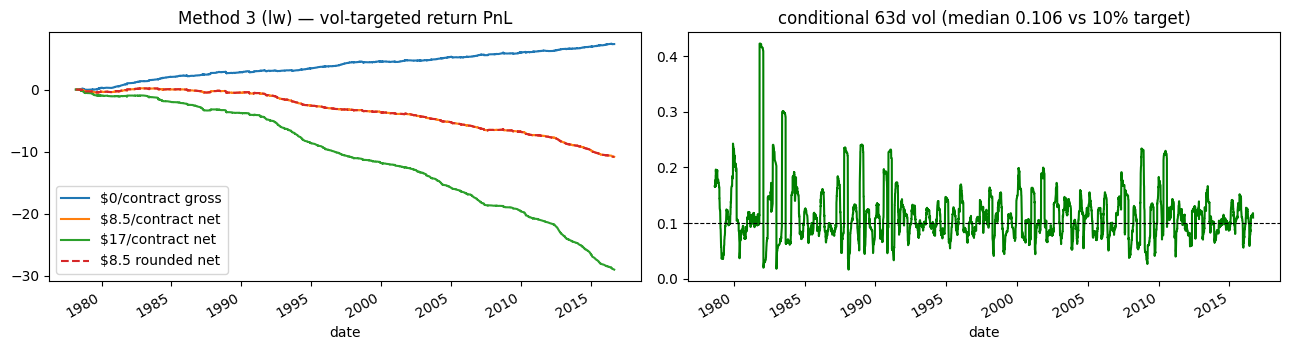

gross IR 1.318 | max leverage 10.00
$8.5 continuous total cost: $18,181,839 | final net return -10.8476
$17 continuous total cost: $36,363,679 | final net return -29.0294
$8.5 rounded total cost: $18,182,188 | final net return -10.8591
max gross contracts (continuous): 5,301.7
max gross contracts (rounded): 5,302


In [8]:
set_section("§6 Transaction costs + vol-targeted PnL",
            intro="Gross vs net cumulative PnL of the Method-3 (Ledoit-Wolf) book under "
                  "$0 / $8.5 / $17-per-contract costs (continuous and integer-rounded), and the "
                  "conditional 63-day realized vol vs the 10% annualized target.")
capital = 1_000_000
cfg0 = StrategyConfig("A", 63, 3, "lw", 252, 63, cost_per_contract_usd=0.0, capital_usd=capital)
cfg85 = StrategyConfig("A", 63, 3, "lw", 252, 63, cost_per_contract_usd=8.5, capital_usd=capital)
cfg17 = StrategyConfig("A", 63, 3, "lw", 252, 63, cost_per_contract_usd=17.0, capital_usd=capital)
cfg85_round = StrategyConfig("A", 63, 3, "lw", 252, 63, cost_per_contract_usd=8.5,
                             capital_usd=capital, round_contracts=True)

r_gross = run_backtest(cfg0, data, changes=ch, dv01=dv01)
r_85 = run_backtest(cfg85, data, changes=ch, dv01=dv01)
r_17 = run_backtest(cfg17, data, changes=ch, dv01=dv01)
r_85_round = run_backtest(cfg85_round, data, changes=ch, dv01=dv01)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
r_gross.pnl_dollar.cumsum().plot(ax=ax[0], label="$0/contract gross")
r_85.net_pnl.cumsum().plot(ax=ax[0], label="$8.5/contract net")
r_17.net_pnl.cumsum().plot(ax=ax[0], label="$17/contract net")
r_85_round.net_pnl.cumsum().plot(ax=ax[0], label="$8.5 rounded net", ls="--")
ax[0].legend(); ax[0].set_title("Method 3 (lw) — vol-targeted return PnL")
cond = (r_gross.pnl_dollar.iloc[63:].rolling(63).std()*np.sqrt(252))
cond.plot(ax=ax[1], color="green"); ax[1].axhline(0.10, color="k", ls="--", lw=0.8)
ax[1].set_title(f"conditional 63d vol (median {cond.median():.3f} vs 10% target)")
plt.tight_layout()
save_fig("fig06_costs_pnl_and_voltarget.png", fig,
         caption="Method 3 (lw): gross vs net PnL under per-contract costs; conditional 63d vol vs 10% target")
plt.show()

say(f"gross IR {r_gross.ir:.3f} | max leverage {r_gross.diagnostics['max_leverage']:.2f}")
say(f"$8.5 continuous total cost: ${r_85.cost_usd.sum():,.0f} | final net return {r_85.net_pnl.sum():.4f}")
say(f"$17 continuous total cost: ${r_17.cost_usd.sum():,.0f} | final net return {r_17.net_pnl.sum():.4f}")
say(f"$8.5 rounded total cost: ${r_85_round.cost_usd.sum():,.0f} | final net return {r_85_round.net_pnl.sum():.4f}")
say(f"max gross contracts (continuous): {r_85.contracts_path.abs().sum(axis=1).max():,.1f}")
say(f"max gross contracts (rounded): {r_85_round.contracts_path.abs().sum(axis=1).max():,.0f}")

## 7. Transaction-cost realism & the trade-to-edge no-trade band

§6 charged a flat dollar fee per contract and rebalanced to target every day. Under
that model the Method-2/3 books are **net-IR negative** — costs swamp the gross edge.
This section asks whether that is a real economic limit or an artifact of the cost
*model* and of daily rebalancing, and builds two composable fixes:

1. **A realistic cost model** (`dv01_bp`) that charges each leg by its own DV01 and a
   pre-registered bid-ask half-spread — instead of one flat fee for a 3M bill and a
   30Y bond alike.
2. **A trade-to-edge no-trade band** that lets the book **drift** between trades —
   holding the executed position until the signal has moved far enough to re-trade.

We close with a pre-registered ±50% viability stress test and an honest GO / NO-GO
verdict. Heavy logic still lives in `pca_rv` (`run_backtest`, `apply_no_trade_band`,
`run_probe`); the notebook only calls it.

### 7.1 Why the flat cost is so punishing

The flat `$/contract` fee bills a 3-month bill leg exactly like a 30-year bond future.
But the factor-neutral hedge holds **far more** short-end contracts — a bill's tiny
DV01 needs a large position to hedge a unit of curve risk — so the bill legs dominate
the contract count, and hence the bill. The left chart shows that the **3M+6M legs are
the bulk of the flat cost**: a cost-*model* artifact, not a real expense, since
short-end bills/futures are among the cheapest instruments to trade. And because cost
scales with capital exactly like the book does, **net IR is capital-invariant** — so
shrinking AUM does not help (capital is not a lever).

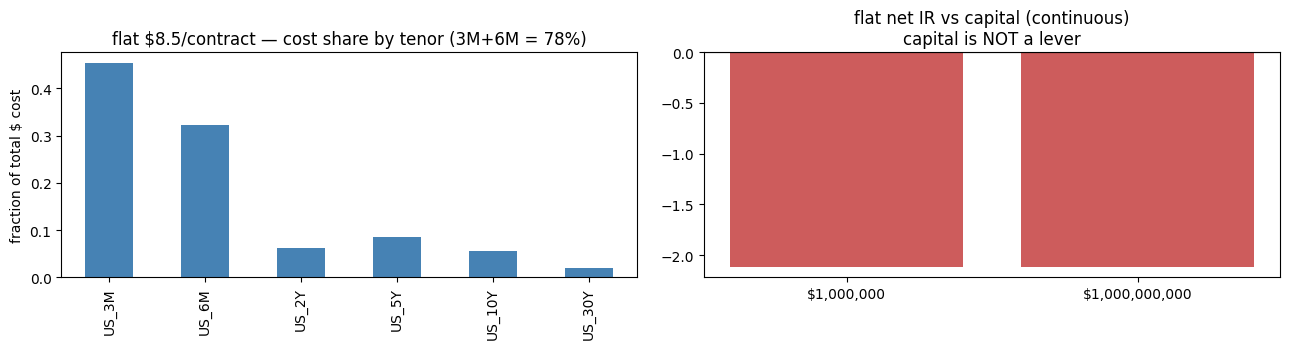

flat $8.5: net IR -2.112 | ann cost drag 46.4% | net IR @ $1e6 vs $1e9 = -2.1124 / -2.1124


In [9]:
set_section("§7.1 Why the flat $/contract cost is so punishing",
            intro="The flat per-contract charge is dominated by the tiny-DV01 bill legs (3M/6M), "
                  "and net IR is invariant to capital on the continuous path — so notional is not a "
                  "lever against cost drag.")
# Diagnose the flat $/contract cost on the §6 Method-3 / Ledoit-Wolf book.
cfg_flat = StrategyConfig("A", 63, 3, "lw", 252, 63, cost_per_contract_usd=8.5,
                          round_contracts=True, capital_usd=1e8)
r_flat = run_backtest(cfg_flat, data, changes=ch, dv01=dv01)
share = pd.Series(r_flat.diagnostics["per_tenor_cost_share"]).reindex(list(config.TENORS))

# Capital invariance: net IR on the continuous (un-rounded) path is scale-free.
inv = {}
for cap in (1e6, 1e9):
    c = StrategyConfig("A", 63, 3, "lw", 252, 63, cost_per_contract_usd=8.5, capital_usd=cap)
    inv[cap] = run_backtest(c, data, changes=ch, dv01=dv01).diagnostics["net_ir"]

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
share.plot.bar(ax=ax[0], color="steelblue")
ax[0].set_title(f"flat $8.5/contract — cost share by tenor "
                f"(3M+6M = {share[['US_3M', 'US_6M']].sum():.0%})")
ax[0].set_ylabel("fraction of total $ cost")
ax[1].bar([f"${c:,.0f}" for c in inv], list(inv.values()), color="indianred")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("flat net IR vs capital (continuous)\ncapital is NOT a lever")
plt.tight_layout()
save_fig("fig07_1_flat_cost_diagnosis.png", fig,
         caption="Flat $8.5/contract: cost share by tenor (left); net IR vs capital (right)")
plt.show()
say(f"flat $8.5: net IR {r_flat.diagnostics['net_ir']:.3f} | "
    f"ann cost drag {r_flat.diagnostics['ann_cost_drag']:.1%} | "
    f"net IR @ $1e6 vs $1e9 = {inv[1e6]:.4f} / {inv[1e9]:.4f}")

### 7.2 A realistic cost model: `dv01_bp`

`dv01_bp` charges each leg `half_spread_bp_i · DV01_i · |Δq_exec_i|` — a one-way yield
half-spread (in bp) times the leg's DV01 times the **executed** change in face. The
half-spreads are *pre-registered* from CME tick/DV01 and bill liquidity (anti-overfit:
fixed before any probe). There is deliberately **no extra ×½** — the quotes are already
one-way half-spreads. Because the charge is DV01-proportional, the tiny-DV01 short end
becomes cheap and the 3M/6M cost share collapses, while the gross book is unchanged
(only the *cost* differs).

,US_3M,US_6M,US_2Y,US_5Y,US_10Y,US_30Y
one-way half-spread (bp),0.25,0.25,0.2,0.1,0.12,0.13


,US_3M,US_6M,US_2Y,US_5Y,US_10Y,US_30Y
one-way half-spread (bp),0.25,0.25,0.2,0.1,0.12,0.13


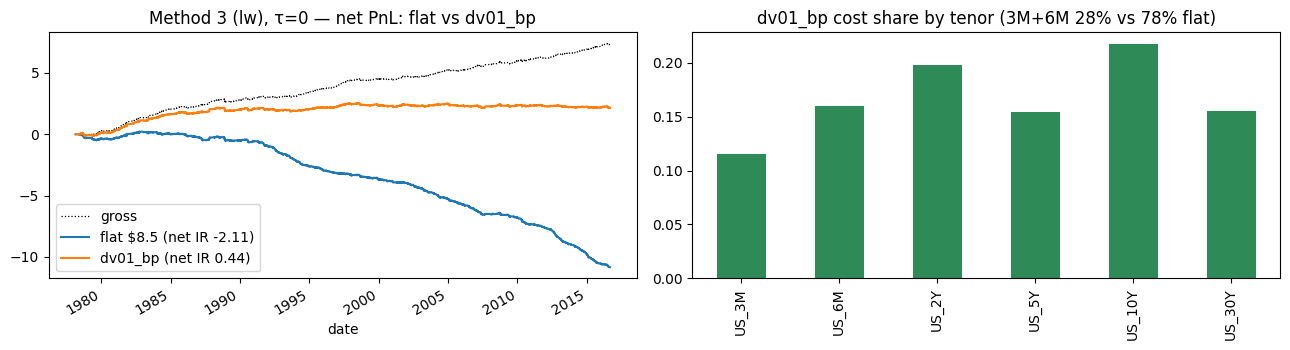

In [10]:
from IPython.display import display
set_section("§7.2 A realistic cost model: dv01_bp",
            intro="Swap the flat per-contract charge for a yield-spread cost (one-way half-spread × "
                  "DV01 × executed change). Net PnL improves and the cost share stops being dominated "
                  "by the bill legs.")
half = pd.Series(config.PREREGISTERED_HALF_SPREADS_BP).reindex(list(config.TENORS))
display(save_table(half.to_frame("one-way half-spread (bp)").T, "tbl07_2_half_spreads",
                   caption="Pre-registered one-way yield half-spreads (bp) by tenor"))

common = dict(round_contracts=True, capital_usd=1e8)
r_flat85 = run_backtest(StrategyConfig("A", 63, 3, "lw", 252, 63, cost_per_contract_usd=8.5,
                                       cost_model="flat", **common), data, changes=ch, dv01=dv01)
r_bp = run_backtest(StrategyConfig("A", 63, 3, "lw", 252, 63, cost_per_contract_usd=8.5,
                                   cost_model="dv01_bp", **common), data, changes=ch, dv01=dv01)
shr = pd.Series(r_bp.diagnostics["per_tenor_cost_share"]).reindex(list(config.TENORS))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
r_flat85.pnl_dollar.cumsum().plot(ax=ax[0], label="gross", color="k", ls=":", lw=0.9)
r_flat85.net_pnl.cumsum().plot(ax=ax[0], label=f"flat $8.5 (net IR {r_flat85.diagnostics['net_ir']:.2f})")
r_bp.net_pnl.cumsum().plot(ax=ax[0], label=f"dv01_bp (net IR {r_bp.diagnostics['net_ir']:.2f})")
ax[0].legend(); ax[0].set_title("Method 3 (lw), τ=0 — net PnL: flat vs dv01_bp")
shr.plot.bar(ax=ax[1], color="seagreen")
ax[1].set_title(f"dv01_bp cost share by tenor "
                f"(3M+6M {shr[['US_3M', 'US_6M']].sum():.0%} vs {share[['US_3M', 'US_6M']].sum():.0%} flat)")
plt.tight_layout()
save_fig("fig07_2_dv01bp_vs_flat.png", fig,
         caption="Net PnL flat vs dv01_bp (left); dv01_bp cost share by tenor (right)")
plt.show()

### 7.3 The trade-to-edge band — letting the weights drift

Instead of rebalancing to the fresh target `G_t = k_t g_t` every day, we hold the
executed book `H_{t-1}` and trade only when it has drifted far enough. Drift is measured
in **risk units**, `r_t = ‖G_t − H_{t-1}‖_Σ / ‖G_t‖_Σ`. Within the band (`r_t ≤ τ`) we
**freeze the integer contracts** — a true no-trade day, and realized vol is allowed to
drift (vol-targeting is suspended between trades, by design). On a breach we trade just
to the **edge** of the band, `H_t = H_{t-1} + (1 − τ/r_t)(G_t − H_{t-1})`; a conditional
re-projection restores exact factor-neutrality whenever the PCA loadings refit. The plot
contrasts the §6 **baseline (daily rebalance)** with the **recommended τ=0.75 band**: the
executed contracts hold flat and snap only on trade days (red).

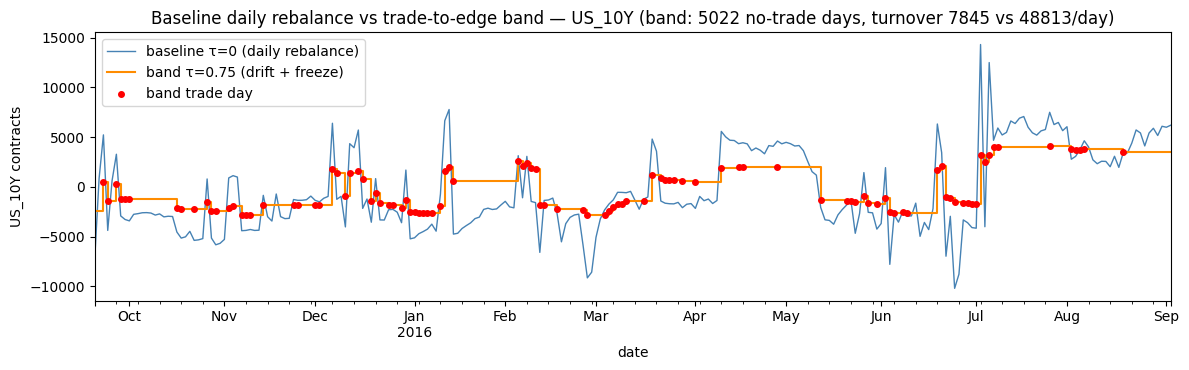

In [11]:
set_section("§7.3 The trade-to-edge no-trade band",
            intro="Holding the book and only trading when the drift exceeds a band τ collapses "
                  "turnover. Shown for US_10Y: baseline daily rebalance vs band (drift + freeze), "
                  "with band trade days marked.")
base = StrategyConfig("A", 63, 2, "sample", 252, 63, cost_per_contract_usd=8.5,
                      round_contracts=True, no_trade_band=0.0, cost_model="dv01_bp", capital_usd=1e8)
band = StrategyConfig("A", 63, 2, "sample", 252, 63, cost_per_contract_usd=8.5,
                      round_contracts=True, no_trade_band=0.75, cost_model="dv01_bp", capital_usd=1e8)
r_base = run_backtest(base, data, changes=ch, dv01=dv01)
r_band = run_backtest(band, data, changes=ch, dv01=dv01)

ten = "US_10Y"
win = r_band.contracts_path[ten].dropna().iloc[-250:].index
fig, ax = plt.subplots(figsize=(12, 3.8))
r_base.contracts_path.loc[win, ten].plot(ax=ax, color="steelblue", lw=1.0,
                                          label="baseline τ=0 (daily rebalance)")
r_band.contracts_path.loc[win, ten].plot(ax=ax, drawstyle="steps-post", color="darkorange",
                                          lw=1.5, label="band τ=0.75 (drift + freeze)")
dc = r_band.contracts_path.loc[win, ten].diff().abs()
trades = dc[dc > 0].index
ax.scatter(trades, r_band.contracts_path.loc[trades, ten], s=16, color="red", zorder=5,
           label="band trade day")
ax.set_ylabel(f"{ten} contracts"); ax.legend()
ax.set_title(f"Baseline daily rebalance vs trade-to-edge band — {ten} "
             f"(band: {r_band.diagnostics['n_true_no_trade_days']} no-trade days, "
             f"turnover {r_band.diagnostics['contract_turnover']:.0f} vs "
             f"{r_base.diagnostics['contract_turnover']:.0f}/day)")
plt.tight_layout()
save_fig("fig07_3_notrade_band_contracts.png", fig,
         caption="US_10Y contracts: baseline daily rebalance vs trade-to-edge band (τ=0.75)")
plt.show()

### 7.4 Sweeping the band width τ

We now switch to the **pre-registered probe recipe** (sample covariance,
z63 / win252 / refit63) and report both Methods 2 and 3. As τ widens, turnover and cost
drag fall sharply and true no-trade days pile up, while **gross IR slowly erodes** (the
held book goes stale) and realized vol drifts below the 10% target. Net IR is the balance
of falling cost against fading gross edge. (`run_probe` is the same engine that produced
the committed verdict CSV, so these live curves and the §7.5 verdict are consistent.)

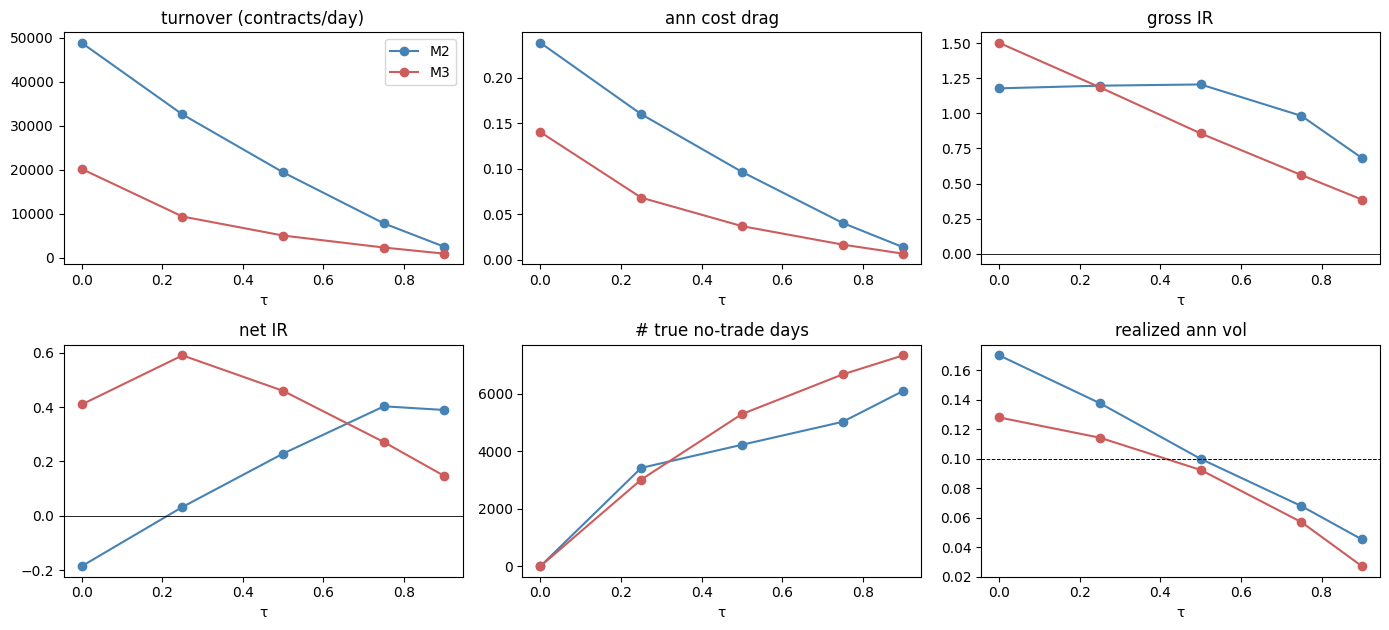

,method,tau,contract_turnover,gross_ir,net_ir,ann_cost_drag,n_true_no_trade_days,realized_ann_vol
0,2,0.00,48812.529,1.179,-0.184,0.238,3,0.170
1,2,0.25,32569.343,1.198,0.033,0.160,3419,0.138
2,2,0.50,19423.240,1.206,0.229,0.096,4224,0.100
3,2,0.75,7845.276,0.982,0.403,0.040,5022,0.068
4,2,0.90,2538.085,0.682,0.389,0.014,6096,0.045
5,3,0.00,20202.749,1.503,0.409,0.140,0,0.128
6,3,0.25,9410.006,1.186,0.590,0.068,3013,0.114
7,3,0.50,5086.877,0.857,0.459,0.037,5292,0.092
8,3,0.75,2372.168,0.561,0.271,0.016,6672,0.057
9,3,0.90,977.931,0.386,0.147,0.006,7334,0.027


,method,tau,contract_turnover,gross_ir,net_ir,ann_cost_drag,n_true_no_trade_days,realized_ann_vol
0,2,0.00,48812.529,1.179,-0.184,0.238,3,0.170
1,2,0.25,32569.343,1.198,0.033,0.160,3419,0.138
2,2,0.50,19423.240,1.206,0.229,0.096,4224,0.100
3,2,0.75,7845.276,0.982,0.403,0.040,5022,0.068
4,2,0.90,2538.085,0.682,0.389,0.014,6096,0.045
5,3,0.00,20202.749,1.503,0.409,0.140,0,0.128
6,3,0.25,9410.006,1.186,0.590,0.068,3013,0.114
7,3,0.50,5086.877,0.857,0.459,0.037,5292,0.092
8,3,0.75,2372.168,0.561,0.271,0.016,6672,0.057
9,3,0.90,977.931,0.386,0.147,0.006,7334,0.027


In [12]:
from pca_rv.probe_no_trade_band import run_probe, summarize_verdict
set_section("§7.4 Sweeping the band width τ",
            intro="τ ∈ {0, 0.25, 0.5, 0.75, 0.9} for Methods 2 & 3: turnover, gross/net IR, annual "
                  "cost drag, true no-trade days, and realized annual vol.")

sweep = run_probe(data, methods=(2, 3), taus=(0.0, 0.25, 0.5, 0.75, 0.9),
                  spread_mults=(1.0,), changes=ch, dv01=dv01)
panels = [("contract_turnover", "turnover (contracts/day)"), ("ann_cost_drag", "ann cost drag"),
          ("gross_ir", "gross IR"), ("net_ir", "net IR"),
          ("n_true_no_trade_days", "# true no-trade days"), ("realized_ann_vol", "realized ann vol")]
fig, axes = plt.subplots(2, 3, figsize=(14, 6.4))
for axp, (col, title) in zip(axes.ravel(), panels):
    for m, color in [(2, "steelblue"), (3, "indianred")]:
        sub = sweep[sweep.method == m].sort_values("tau")
        axp.plot(sub.tau, sub[col], marker="o", color=color, label=f"M{m}")
    axp.set_title(title); axp.set_xlabel("τ")
    if col in ("net_ir", "gross_ir"):
        axp.axhline(0, color="k", lw=0.6)
    if col == "realized_ann_vol":
        axp.axhline(0.10, color="k", ls="--", lw=0.7)
axes[0, 0].legend()
plt.tight_layout()
save_fig("fig07_4_tau_sweep_grid.png", fig,
         caption="Band-width τ sweep (Methods 2 & 3): turnover, cost drag, gross/net IR, no-trade days, realized vol")
plt.show()
save_table(sweep[["method", "tau", "contract_turnover", "gross_ir", "net_ir", "ann_cost_drag",
                  "n_true_no_trade_days", "realized_ann_vol"]].round(3),
           "tbl07_4_tau_sweep", index=False,
           caption="Band-width τ sweep metrics (Methods 2 & 3)")

### 7.5 Is it actually viable? A pre-registered ±50% stress

The GO gate is deliberately strict and **anti-overfit** — the half-spreads were fixed
*before* the probe. A `(method, τ)` cell is viable only if its net IR is **positive at
the central quote, still positive at a +50% wider spread, and still positive after
removing the 3M/6M bill-proxy cost** (so the result is not an artifact of the cheap short
end). The shaded band spans the ±50% spread stress; the dashed line is net IR excluding
the proxy legs. The full method × τ × spread grid is loaded from the committed
`probe_results_no_trade_band.csv` (produced once by `write_probe_outputs`).

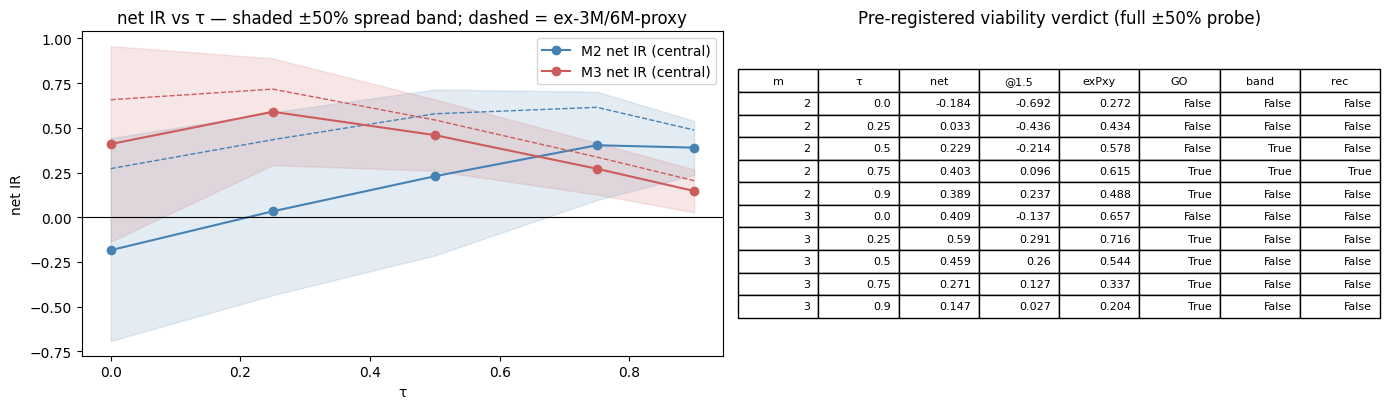

OVERALL: GO | recommended (viable & healthy band): [{'method': 2, 'tau': 0.75}]


,method,tau,net_ir,net_ir_at_1.5,net_ir_ex_proxy,go_ac5,gross_ir_ratio,turnover_drop,cost_drag_drop,band_success_ac4,recommended
0,2,0.00,-0.184,-0.692,0.272,False,1.000,0.000,0.000,False,False
1,2,0.25,0.033,-0.436,0.434,False,1.016,0.333,0.329,False,False
2,2,0.50,0.229,-0.214,0.578,False,1.023,0.602,0.595,True,False
3,2,0.75,0.403,0.096,0.615,True,0.833,0.839,0.831,True,True
4,2,0.90,0.389,0.237,0.488,True,0.579,0.948,0.943,False,False
5,3,0.00,0.409,-0.137,0.657,False,1.000,0.000,0.000,False,False
6,3,0.25,0.590,0.291,0.716,True,0.789,0.534,0.514,False,False
7,3,0.50,0.459,0.260,0.544,True,0.571,0.748,0.737,False,False
8,3,0.75,0.271,0.127,0.337,True,0.373,0.883,0.882,False,False
9,3,0.90,0.147,0.027,0.204,True,0.257,0.952,0.954,False,False


,method,tau,net_ir,net_ir_at_1.5,net_ir_ex_proxy,go_ac5,gross_ir_ratio,turnover_drop,cost_drag_drop,band_success_ac4,recommended
0,2,0.00,-0.184,-0.692,0.272,False,1.000,0.000,0.000,False,False
1,2,0.25,0.033,-0.436,0.434,False,1.016,0.333,0.329,False,False
2,2,0.50,0.229,-0.214,0.578,False,1.023,0.602,0.595,True,False
3,2,0.75,0.403,0.096,0.615,True,0.833,0.839,0.831,True,True
4,2,0.90,0.389,0.237,0.488,True,0.579,0.948,0.943,False,False
5,3,0.00,0.409,-0.137,0.657,False,1.000,0.000,0.000,False,False
6,3,0.25,0.590,0.291,0.716,True,0.789,0.534,0.514,False,False
7,3,0.50,0.459,0.260,0.544,True,0.571,0.748,0.737,False,False
8,3,0.75,0.271,0.127,0.337,True,0.373,0.883,0.882,False,False
9,3,0.90,0.147,0.027,0.204,True,0.257,0.952,0.954,False,False


In [13]:
set_section("§7.5 Pre-registered ±50% viability gate",
            intro="Viability gate: net IR must stay positive at 1.0× and 1.5× spreads and without "
                  "the 3M/6M proxy legs. The verdict table flags GO/NO-GO and the recommended cells.")
full = pd.read_csv(ROOT / "proj" / "pca_rv" / "probe_results_no_trade_band.csv")
verdict = summarize_verdict(full)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for m, color in [(2, "steelblue"), (3, "indianred")]:
    g = full[full.method == m]
    piv = g.pivot(index="tau", columns="spread_mult", values="net_ir").sort_index()
    ax[0].plot(piv.index, piv[1.0], marker="o", color=color, label=f"M{m} net IR (central)")
    ax[0].fill_between(piv.index, piv[0.5], piv[1.5], color=color, alpha=0.15)
    ex = g[g.spread_mult == 1.0].sort_values("tau")
    ax[0].plot(ex.tau, ex.net_ir_ex_proxy, ls="--", color=color, lw=1.0)
ax[0].axhline(0, color="k", lw=0.8); ax[0].set_xlabel("τ"); ax[0].set_ylabel("net IR")
ax[0].set_title("net IR vs τ — shaded ±50% spread band; dashed = ex-3M/6M-proxy")
ax[0].legend()

vt = verdict[["method", "tau", "net_ir", "net_ir_at_1.5", "net_ir_ex_proxy",
              "go_ac5", "band_success_ac4", "recommended"]].round(3)
ax[1].axis("off")
tbl = ax[1].table(cellText=vt.values,
                  colLabels=["m", "τ", "net", "@1.5", "exPxy", "GO", "band", "rec"], loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.35)
ax[1].set_title("Pre-registered viability verdict (full ±50% probe)")
plt.tight_layout()
save_fig("fig07_5_viability_gate.png", fig,
         caption="Net IR vs τ with ±50% spread band (left); pre-registered viability verdict table (right)")
plt.show()

go = bool(verdict.go_ac5.any())
rec = verdict[verdict.recommended][["method", "tau"]].to_dict("records")
say("OVERALL:", "GO" if go else "NO-GO", "| recommended (viable & healthy band):", rec)
save_table(verdict.round(3), "tbl07_5_viability_verdict", index=False,
           caption="Pre-registered ±50% viability verdict (all methods × τ)")

### 7.6 What we learned

- **The cost problem was largely a cost-*model* artifact.** Under DV01-proportional
  costs the gross edge survives: several `(method, τ)` cells clear the strict ±50%
  viability gate. **Overall verdict: GO.**
- **The recommended operating point is Method 2 at τ ≈ 0.75** — net IR ≈ 0.40, still
  ≈ 0.10 > 0 at a +50% wider spread, and ≈ 0.61 excluding the bill proxy. It is the one
  cell that is both viable *and* a **healthy band** (gross IR preserved ≥ 80% while
  cutting turnover and cost drag by ≥ 50%).
- **Method 3 stays net-positive at every τ, but its gross IR erodes > 20%** once it
  holds (staleness), so it fails the band-health bar even though it is not loss-making.
- **Caveats (tracked, not silent).** The Sharpe is thin (~0.1–0.4). The engine omits
  **carry / roll-down**, which the band makes *more* material by lengthening holding
  periods — this must be measured before trusting the banded net IR. DV01 uses cash/par,
  not the futures CTD-forward DV01; quarterly roll costs are unmodeled. Any of these
  could move a thin verdict.

## 8. Imperfect factor hedging — trade only {2Y, 5Y, 10Y}

### 8.1 Why relax exact neutrality

§7 concluded that hedging all 3 PC factors with **all 6 tenors** makes the per-day leg
count (and `dv01_bp` cost) so high that costs overwhelm the spread PnL. The cheaper book
trades only the **3 most-liquid points** `D = {US_2Y, US_5Y, US_10Y}` and accepts
*imperfect* factor neutrality instead of forcing `V g = 0`.

The PCA + residual signals stay on the honest full 6-tenor factor model; only the **book
support** shrinks to `D`. The view is `α = −s·σ` on those 3 tenors; factor leakage is
*bounded*, not zeroed.

### 8.2 Theory — 3 instruments, 3 factors ⇒ exact neutrality is infeasible

With exactly 3 tradable instruments and 3 PC factors the restricted loadings `V_D` is 3×3
full-rank, so the **only** exactly-neutral book is `g = 0` — no trade. Relaxing to a bounded
leakage objective is therefore *required*. We add a closed-form quadratic penalty:

- **Method 3** `max α_Dᵀg − (γ/2)g_DᵀΣ_D g_D − (λ/2)‖V_D g‖²  ⇒  g_D = (γΣ_D + λV_DᵀV_D)⁻¹α_D`
- **Method 2** `min ½ g_Dᵀ(Σ_D + λV_DᵀV_D)g_D  s.t.  pins` (no `Vg=0` row).

`λ→0` is the unconstrained restricted-MV book (max alpha, max leakage); `λ→∞` drives
`g_D→0` (the no-trade limit of exact neutrality). The meaningful knob is `λ/γ`.

**Duality vs the ∞-norm cap.** The penalty `λ‖V_D g‖²` is the Lagrangian dual of the
**2-norm ball** `‖V_D g‖₂ ≤ ε`, *not* the ∞-norm. So the closed-form penalty must reproduce
the literal 2-norm-ball QP at the matched `ε` (validated in §8.5), while the per-factor
**∞-norm cap** `‖V_D g‖∞ ≤ ε` is a *different* feasible set — its frontier may differ, and
that difference is an analysis deliverable, not a bug.

GAMMA (full) = 3171.2   GAMMA_D (restricted, TRAIN) = 1437.1


lambda*/gamma_D per method (argmax VAL net IR, dv01_bp): {'M2': 100.0, 'M2-all': 'determined', 'M3': 0.0}



A/B - exact-6 vs trade-3 (VAL; scale-invariant IRs + dimensionless leakage):


,method,universe,cost,gross_IR,net_IR,net/gross,leak_dimless,turnover
0,M2,exact-6,flat,1.1614,1.3542,1.1660,0.0000,0.0054
1,M2,exact-6,dv01_bp,1.1614,-0.5077,-0.4372,0.0000,0.0054
2,M2,trade-3,flat,0.6730,0.6756,1.0038,0.1910,0.0044
3,M2,trade-3,dv01_bp,0.6730,-0.3673,-0.5458,0.1910,0.0044
4,M2-all,exact-6,flat,0.0131,-0.4026,-30.8204,0.0000,0.0093
5,M2-all,exact-6,dv01_bp,0.0131,-1.4454,-110.6652,0.0000,0.0093
6,M2-all,trade-3,flat,0.1497,-0.1021,-0.6818,0.5091,0.0012
7,M2-all,trade-3,dv01_bp,0.1497,-0.4609,-3.0780,0.5091,0.0012
8,M3,exact-6,flat,1.4960,1.5040,1.0053,0.0000,0.0035
9,M3,exact-6,dv01_bp,1.4960,-0.1222,-0.0817,0.0000,0.0035


,method,universe,cost,gross_IR,net_IR,net/gross,leak_dimless,turnover
0,M2,exact-6,flat,1.1614,1.3542,1.1660,0.0000,0.0054
1,M2,exact-6,dv01_bp,1.1614,-0.5077,-0.4372,0.0000,0.0054
2,M2,trade-3,flat,0.6730,0.6756,1.0038,0.1910,0.0044
3,M2,trade-3,dv01_bp,0.6730,-0.3673,-0.5458,0.1910,0.0044
4,M2-all,exact-6,flat,0.0131,-0.4026,-30.8204,0.0000,0.0093
5,M2-all,exact-6,dv01_bp,0.0131,-1.4454,-110.6652,0.0000,0.0093
6,M2-all,trade-3,flat,0.1497,-0.1021,-0.6818,0.5091,0.0012
7,M2-all,trade-3,dv01_bp,0.1497,-0.4609,-3.0780,0.5091,0.0012
8,M3,exact-6,flat,1.4960,1.5040,1.0053,0.0000,0.0035
9,M3,exact-6,dv01_bp,1.4960,-0.1222,-0.0817,0.0000,0.0035



§8 winner = M3 trade-3, lambda*/gamma_D = 0, VAL net IR = -0.013


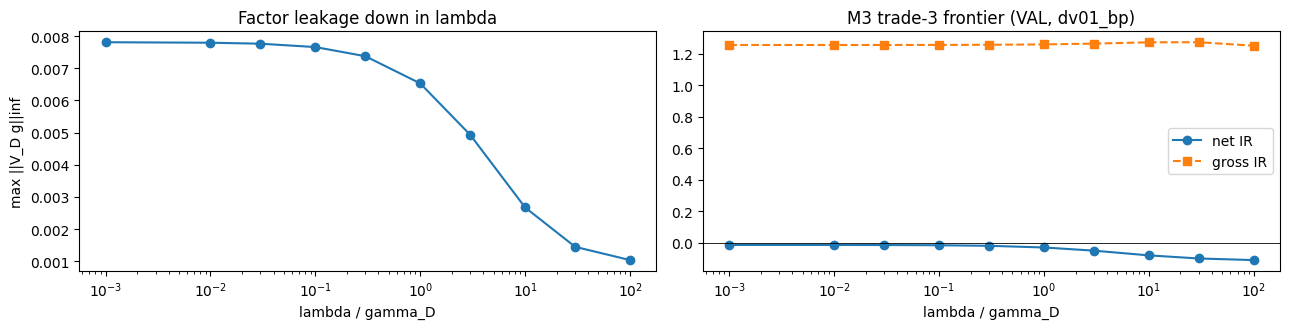

In [14]:
# §8.3 — A/B: exact-6 (Vg=0) vs trade-3 {2Y,5Y,10Y} closed-form penalty.
import bisect
from IPython.display import display
from pca_rv.backtest import compute_signal
from pca_rv.residual import block_params, block_sigma
from pca_rv.weights import method3_alpha, method3_meanvar_penalty
from pca_rv.grid import TRADE3_TENORS
from pca_rv.metrics import information_ratio, max_drawdown
set_section("§8 Imperfect factor hedging — trade-3 {2Y, 5Y, 10Y}",
            intro="Relax exact factor neutrality to a bounded leakage penalty λ‖V_D g‖² on a "
                  "3-instrument book. Calibrate GAMMA_D on TRAIN, pick λ* per method on VAL net IR, "
                  "compare exact-6 vs trade-3 across flat/dv01_bp costs, and trace the λ frontier.")

support = [list(config.TENORS).index(t) for t in TRADE3_TENORS]

# GAMMA_D: calibrate γ on TRAIN, restricted to D (pure scalar ⇒ IR-invariant; anchor only).
ch_train = data.changes_bp.loc[:data.train_idx[-1]]
out_train = forward_residuals_cov(ch_train, window=252, block=63, cov_method="ledoit_wolf")
s_tr = compute_signal(StrategyConfig("A", 63, 3, "lw", 252, 63, 0.0), out_train)
g_cal = pd.DataFrame(0.0, index=s_tr.index, columns=s_tr.columns)
for t in s_tr.index:
    if not s_tr.loc[t].notna().any():
        continue
    sr = np.nan_to_num(s_tr.loc[t].to_numpy())
    _, V = block_params(out_train, t); Sig = block_sigma(out_train, t)
    a = method3_alpha(sr, np.sqrt(np.clip(np.diag(Sig), 0.0, None)))
    g_cal.loc[t] = method3_meanvar_penalty(a, V, Sig, support, gamma=1.0, lam=0.0)
pnl_cal = (g_cal.shift(1) * ch_train.reindex(g_cal.index)).sum(axis=1).iloc[1:]
GAMMA_D = float(pnl_cal.std(ddof=1) * np.sqrt(252) / config.VOL_TARGET_ANN)
say(f"GAMMA (full) = {config.GAMMA:.1f}   GAMMA_D (restricted, TRAIN) = {GAMMA_D:.1f}")


def _val_net_ir(res):
    return information_ratio(res.net_pnl.loc[res.net_pnl.index.isin(data.val_idx)])


# dimensionless leakage  mean‖V_D g‖ / mean‖g‖  over the VAL book (scale-invariant, 1A').
_rd = list(out["refit_dates"])
def _dless_leak(res, idx=None):
    idx = data.val_idx if idx is None else idx
    W = res.weights_path.reindex(idx).dropna(how="all")
    if len(W) == 0:
        return 0.0
    arr, dates = W.to_numpy(), list(W.index)
    leak = gnorm = 0.0
    for i, d in enumerate(dates):
        k = bisect.bisect_right(_rd, d) - 1
        if k < 0:
            continue
        Vk = out["loadings_panel"][_rd[k]]
        leak += float(np.linalg.norm(Vk @ arr[i])); gnorm += float(np.linalg.norm(arr[i]))
    return leak / gnorm if gnorm > 0 else 0.0


ARMS = [("M2", dict(method=2, method2_mode="single")),
        ("M2-all", dict(method=2, method2_mode="all")),
        ("M3", dict(method=3, method2_mode="single"))]
LAMBDA_GRID = tuple(GAMMA_D * x for x in (0.0, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 1e1, 3e1, 1e2))

# λ* per method on VAL net IR (dv01_bp). M2-all on 3 legs is fully determined (penalty inert,
# pre-mortem P3) ⇒ no real frontier ⇒ excluded from λ-selection.
lam_star = {}
for name, kw in ARMS:
    if kw["method"] == 2 and kw["method2_mode"] == "all":
        lam_star[name] = None
        continue
    best_ir, best_lam = -np.inf, 0.0
    for lam in LAMBDA_GRID:
        c = StrategyConfig("A", 63, covariance="lw", pca_window=252, refit=63,
                           cost_per_contract_usd=0.0, cost_model="dv01_bp",
                           trade_tenors=TRADE3_TENORS, neutrality_mode="penalty",
                           neutrality_lambda=lam, **kw)
        ir = _val_net_ir(run_backtest(c, data, changes=ch, residual_out=out, dv01=dv01, gamma=GAMMA_D))
        if ir > best_ir:
            best_ir, best_lam = ir, lam
    lam_star[name] = best_lam
say("lambda*/gamma_D per method (argmax VAL net IR, dv01_bp):",
    {k: ("determined" if v is None else round(v / GAMMA_D, 3)) for k, v in lam_star.items()})

# A/B table — {exact-6, trade-3} x {flat, dv01_bp} per method (VAL; scale-invariant metrics).
rows = []
for name, kw in ARMS:
    lam = 0.0 if lam_star[name] is None else lam_star[name]
    universes = [("exact-6", dict(neutrality_mode="exact"), None),
                 ("trade-3", dict(neutrality_mode="penalty", trade_tenors=TRADE3_TENORS,
                                  neutrality_lambda=lam), GAMMA_D)]
    for uni, ukw, gam in universes:
        for cm in ("flat", "dv01_bp"):
            c = StrategyConfig("A", 63, covariance="lw", pca_window=252, refit=63,
                               cost_per_contract_usd=0.0, cost_model=cm, **kw, **ukw)
            r = run_backtest(c, data, changes=ch, residual_out=out, dv01=dv01, gamma=gam)
            net, gross = _val_net_ir(r), r.diagnostics["gross_ir"]
            rows.append({"method": name, "universe": uni, "cost": cm,
                         "gross_IR": gross, "net_IR": net,
                         "net/gross": (net / gross if gross else np.nan),
                         "leak_dimless": _dless_leak(r), "turnover": r.turnover})
ab = pd.DataFrame(rows)
say("\nA/B - exact-6 vs trade-3 (VAL; scale-invariant IRs + dimensionless leakage):")
display(save_table(ab.round(4), "tbl08_ab_exact6_vs_trade3", index=False,
                   caption="A/B — exact-6 vs trade-3 (VAL; scale-invariant IRs + dimensionless leakage)"))

# winner: trade-3, dv01_bp, best VAL net IR (exclude the determined M2-all arm).
cand = ab[(ab.universe == "trade-3") & (ab.cost == "dv01_bp") & (ab.method != "M2-all")]
wrow = cand.loc[cand.net_IR.idxmax()]
WIN_NAME = wrow["method"]; WIN_KW = dict(ARMS)[WIN_NAME]
WIN_LAM = 0.0 if lam_star[WIN_NAME] is None else lam_star[WIN_NAME]
winner_cfg = StrategyConfig("A", 63, covariance="lw", pca_window=252, refit=63,
                            cost_per_contract_usd=0.0, cost_model="dv01_bp",
                            trade_tenors=TRADE3_TENORS, neutrality_mode="penalty",
                            neutrality_lambda=WIN_LAM, **WIN_KW)
say(f"\n§8 winner = {WIN_NAME} trade-3, lambda*/gamma_D = {WIN_LAM / GAMMA_D:.3g}, "
    f"VAL net IR = {wrow.net_IR:.3f}")

# lambda-frontier (M3 trade-3): leakage down in lambda; net vs gross IR over the sweep.
fr = []
for lam in LAMBDA_GRID:
    c = StrategyConfig("A", 63, 3, "lw", 252, 63, 0.0, trade_tenors=TRADE3_TENORS,
                       neutrality_mode="penalty", neutrality_lambda=lam, cost_model="dv01_bp")
    r = run_backtest(c, data, changes=ch, residual_out=out, dv01=dv01, gamma=GAMMA_D)
    fr.append({"lam_over_g": lam / GAMMA_D, "leakage": r.diagnostics["max_factor_leakage"],
               "gross_IR": r.diagnostics["gross_ir"], "net_IR": _val_net_ir(r)})
frd = pd.DataFrame(fr)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].semilogx(frd.lam_over_g.clip(lower=1e-3), frd.leakage, "o-")
ax[0].set_xlabel("lambda / gamma_D"); ax[0].set_ylabel("max ||V_D g||inf"); ax[0].set_title("Factor leakage down in lambda")
ax[1].semilogx(frd.lam_over_g.clip(lower=1e-3), frd.net_IR, "o-", label="net IR")
ax[1].semilogx(frd.lam_over_g.clip(lower=1e-3), frd.gross_IR, "s--", label="gross IR")
ax[1].axhline(0, color="k", lw=0.6); ax[1].legend(); ax[1].set_xlabel("lambda / gamma_D")
ax[1].set_title("M3 trade-3 frontier (VAL, dv01_bp)")
plt.tight_layout()
save_fig("fig08_lambda_frontier.png", fig,
         caption="Factor leakage vs λ/γ_D (left); M3 trade-3 net/gross IR frontier (right)")
plt.show()

In [15]:
# §8.5 — cvxpy hard-inequality cross-check (skip-gated validation side-channel).
# The production engine never imports cvxpy; this only proves duality on a sampled day.
set_section("§8.5 cvxpy duality cross-check",
            intro="Optional validation: a 2-norm-ball QP reproduces the closed-form penalty book to "
                  "solver tolerance (duality), confirming the engine's closed form. Skips cleanly if "
                  "cvxpy is not installed.")
try:
    import cvxpy  # noqa: F401
    from pca_rv.weights_cvx import method3_hardcap

    s_dbg = compute_signal(StrategyConfig("A", 63, 3, "lw", 252, 63, 0.0), out)
    active = s_dbg.dropna(how="all")
    t_dbg = active.index[len(active) // 2]
    _, Vd = block_params(out, t_dbg); Sigd = block_sigma(out, t_dbg)
    sr = np.nan_to_num(s_dbg.loc[t_dbg].to_numpy())
    alpha_dbg = method3_alpha(sr, np.sqrt(np.clip(np.diag(Sigd), 0.0, None)))
    cc = []
    for lam in (0.3 * GAMMA_D, 3.0 * GAMMA_D, 30.0 * GAMMA_D):
        g_pen = method3_meanvar_penalty(alpha_dbg, Vd, Sigd, support, gamma=GAMMA_D, lam=lam)
        eps2 = float(np.linalg.norm(Vd @ g_pen))                # ||V_D g||_2 at this lambda
        g_q2 = method3_hardcap(alpha_dbg, Vd, Sigd, support, gamma=GAMMA_D, eps=eps2, norm="2")
        g_qi = method3_hardcap(alpha_dbg, Vd, Sigd, support, gamma=GAMMA_D, eps=eps2, norm="inf")
        cc.append({"lam/g_D": round(lam / GAMMA_D, 2), "eps(2norm)": eps2,
                   "max|penalty - QP_2norm|": float(np.max(np.abs(g_pen - g_q2))),
                   "leak_inf(QP_inf)<=eps": bool(float(np.max(np.abs(Vd @ g_qi))) <= eps2 + 1e-6),
                   "max|QP_2norm - QP_inf|": float(np.max(np.abs(g_q2 - g_qi)))})
    display(save_table(pd.DataFrame(cc), "tbl08_5_cvxpy_crosscheck", index=False,
                       caption="cvxpy cross-check: closed-form penalty vs QP (2-norm / inf-norm)"))
    say(f"cvxpy cross-check at {t_dbg.date()}: the 2-norm-ball QP reproduces the closed-form "
        "penalty to solver tol (duality verified); the inf-norm cap is a distinct feasible "
        "set (its book differs at the same eps).")
except Exception as exc:                                        # cvxpy absent / solver issue
    say(f"[8.5 cvxpy cross-check SKIPPED] {type(exc).__name__}: {exc}")
    say("Install with `uv pip install cvxpy` to run the duality validation; the suite/notebook "
        "pass without it.")

,lam/g_D,eps(2norm),max|penalty - QP_2norm|,leak_inf(QP_inf)<=eps,max|QP_2norm - QP_inf|
0,0.3,0.000157,2.596235e-11,True,0.000005
1,3.0,0.000142,2.961370e-11,True,0.000036
2,30.0,0.000081,2.391949e-09,True,0.000051


,lam/g_D,eps(2norm),max|penalty - QP_2norm|,leak_inf(QP_inf)<=eps,max|QP_2norm - QP_inf|
0,0.3,0.000157,2.596235e-11,True,0.000005
1,3.0,0.000142,2.961370e-11,True,0.000036
2,30.0,0.000081,2.391949e-09,True,0.000051


cvxpy cross-check at 1997-11-12: the 2-norm-ball QP reproduces the closed-form penalty to solver tol (duality verified); the inf-norm cap is a distinct feasible set (its book differs at the same eps).


### 8.4 Decision

The A/B (VAL, `dv01_bp`) shows the trade-3 penalty book earns **lower gross** IR than exact-6
(it gives up the diversification of the full 6-tenor neutral subspace) but incurs **far less
cost drag** (fewer legs ⇒ lower turnover), so its **net** IR is *less negative* than exact-6's under the
realistic cost model (both are negative without the §7 band — trade-3 is simply far more cost-resilient). Method-2-all is fully determined on 3 legs (penalty inert) — an
informative null, excluded from λ-selection. The chosen imperfect winner (printed above, by
VAL net IR) carries forward to the §9 MOVE overlay. The λ-frontier confirms leakage decreases
monotonically in λ while gross IR erodes — the relaxation buys cost-resilience, paid in alpha.

[MOVE] spliced OK (corr=1.0000, rel_err=0.0000): 2026-05-29 → 2026-05-29 (+0 rows; backup=on)
MOVE realized coverage: 1990-01-02 -> 2026-05-29 | spans test window (to 2026-05-21): True
MOVE distribution: mean 92.1 | 75th 109 | 90th 125 | 95th 138


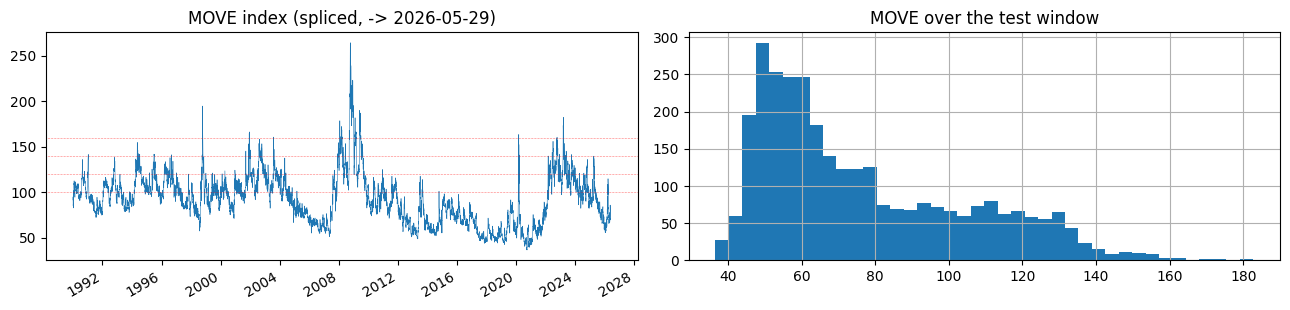

In [16]:
# §9.1 — complete the MOVE series (download + overlap-gated splice), coverage + distribution.
from pca_rv.data import complete_move_series
set_section("§9.1 MOVE series completion + coverage",
            intro="Complete the MOVE index (download + overlap-gated splice, idempotent with a .bak "
                  "backup), confirm it spans the TEST window, and show its level history and the "
                  "test-window distribution used to pick the regime threshold θ.")

mv = complete_move_series(write=True, backup=True)   # idempotent; .bak preserves the original CSV
move = mv["series"]
cov0, cov1 = move.index.min(), move.index.max()
spans_test = cov1 >= data.test_idx[-1]
say(f"MOVE realized coverage: {cov0.date()} -> {cov1.date()} | spans test "
    f"window (to {data.test_idx[-1].date()}): {spans_test}")
if not spans_test:
    say(f"  [R3 CAVEAT] download unavailable/failed - 9 TEST coverage TRUNCATED at {cov1.date()};")
    say("  the MOVE results below cover only <= that date, NOT the full test split.")
q = move.quantile([0.75, 0.90, 0.95])
say(f"MOVE distribution: mean {move.mean():.1f} | 75th {q.loc[0.75]:.0f} | "
    f"90th {q.loc[0.90]:.0f} | 95th {q.loc[0.95]:.0f}")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
move.plot(ax=ax[0], lw=0.4); ax[0].set_title(f"MOVE index (spliced, -> {cov1.date()})")
for th in (100, 120, 140, 160):
    ax[0].axhline(th, color="r", lw=0.4, ls=":")
move.loc[data.test_idx[0]:].hist(ax=ax[1], bins=40)
ax[1].set_title("MOVE over the test window"); plt.tight_layout()
save_fig("fig09_move_series_and_hist.png", fig,
         caption="MOVE index history with candidate thresholds (left); MOVE over the test window (right)")
plt.show()

### 9.2 The causal exit mechanic

The filter is a **binary regime overlay**: on any day with `MOVE_t > θ` the entire book is
zeroed. Because `MOVE_t` (close of day *t*) zeroes the book that is realized on `Δy_{t+1}`
(via the engine's `shift(lag)`), the rule is strictly causal — it uses only information ≤ *t*.
It overrides any no-trade-band freeze (`hold_mask & ~exit_mask`), so a regime exit always
flattens the book rather than carrying a stale one. We run it with **vol-targeting OFF** and a
**TRAIN-frozen scalar-c** so every θ-arm shares one common gross-vol anchor (the arms differ
only in which days are zeroed).

In [17]:
# §9.3 — MOVE overlay on the §8 winner: scalar-c (TRAIN), theta-sweep (VAL), TEST capstone (once).
set_section("§9.3 MOVE overlay — θ-sweep (VAL) + TEST capstone",
            intro="Freeze the vol-target scalar c on TRAIN, sweep the MOVE threshold θ on VAL, and "
                  "run the single TEST touch for the imperfect+MOVE strategy: no-filter vs MOVE-θ* "
                  "net IR, MDD and cumulative return.")
def _winner(vol_target=False, move_threshold=None):
    return StrategyConfig("A", 63, covariance="lw", pca_window=252, refit=63,
                          cost_per_contract_usd=0.0, cost_model="dv01_bp", vol_target=vol_target,
                          trade_tenors=TRADE3_TENORS, neutrality_mode="penalty",
                          neutrality_lambda=WIN_LAM, move_threshold=move_threshold, **WIN_KW)

# scalar-c so the NO-FILTER book ~ 10% ann gross vol on TRAIN (leakage-safe: TRAIN only).
r_tr = run_backtest(_winner(), data, changes=ch_train, dv01=dv01, gamma=GAMMA_D)
gross_vol_tr = float(r_tr.pnl_dollar.std(ddof=1) * np.sqrt(252))
scalar_c = config.VOL_TARGET_ANN / gross_vol_tr
say(f"scalar-c (TRAIN-frozen): TRAIN gross vol {gross_vol_tr:.4f} -> c = {scalar_c:.3f}")

say("\ntheta-sweep on VAL (vol-target OFF + scalar-c; no test data touched):")
rows = []
for theta in (None, 100, 120, 140, 160):
    r = run_backtest(_winner(move_threshold=(None if theta is None else float(theta))),
                     data, changes=ch, residual_out=out, dv01=dv01, gamma=GAMMA_D,
                     book_scale=scalar_c, move=(None if theta is None else move))
    nv = r.net_pnl.loc[r.net_pnl.index.isin(data.val_idx)]
    rows.append({"theta": "none" if theta is None else theta,
                 "net_IR": information_ratio(nv), "ann_std": float(nv.std() * np.sqrt(252)),
                 "MDD": max_drawdown(nv), "cum_ret": float(nv.sum()),
                 "n_filtered": r.diagnostics["n_move_filtered_days"]})
mt = pd.DataFrame(rows)
from IPython.display import display
display(save_table(mt.round(4), "tbl09_theta_sweep_val", index=False,
                   caption="MOVE threshold θ-sweep on VAL (vol-target OFF + scalar-c)"))
filt = mt[mt.theta != "none"]
theta_star = int(filt.loc[filt.net_IR.idxmax(), "theta"])
say(f"theta* (argmax VAL net IR) = {theta_star}")

# TEST capstone - the single TEST touch for the imperfect+MOVE strategy.
r_cap = run_backtest(_winner(move_threshold=float(theta_star)), data, changes=data.changes_bp,
                     dv01=dv01, gamma=GAMMA_D, book_scale=scalar_c, move=move)
r_nf = run_backtest(_winner(), data, changes=data.changes_bp, dv01=dv01, gamma=GAMMA_D,
                    book_scale=scalar_c)
tnet = r_cap.net_pnl.loc[r_cap.net_pnl.index.isin(data.test_idx)]
tnet0 = r_nf.net_pnl.loc[r_nf.net_pnl.index.isin(data.test_idx)]
say(f"\nTEST capstone ({WIN_NAME} trade-3, lambda*/gamma_D={WIN_LAM / GAMMA_D:.3g}, theta*={theta_star}) "
    "- FIRST & ONLY test touch for this strategy:")
say(f"  no-filter : net IR {information_ratio(tnet0):6.3f} | MDD {max_drawdown(tnet0):.3f} "
    f"| cum {tnet0.sum():.3f}")
say(f"  MOVE th*  : net IR {information_ratio(tnet):6.3f} | MDD {max_drawdown(tnet):.3f} "
    f"| cum {tnet.sum():.3f} | filtered {r_cap.diagnostics['n_move_filtered_days']}d")

scalar-c (TRAIN-frozen): TRAIN gross vol 0.1000 -> c = 1.000

theta-sweep on VAL (vol-target OFF + scalar-c; no test data touched):


,theta,net_IR,ann_std,MDD,cum_ret,n_filtered
0,none,0.0078,0.0794,0.1997,0.0062,0
1,100,0.1587,0.0647,0.1097,0.1031,2960
2,120,0.1592,0.0742,0.1097,0.1185,991
3,140,0.1976,0.0750,0.1097,0.1488,359
4,160,0.1452,0.0761,0.1097,0.1110,150


,theta,net_IR,ann_std,MDD,cum_ret,n_filtered
0,none,0.0078,0.0794,0.1997,0.0062,0
1,100,0.1587,0.0647,0.1097,0.1031,2960
2,120,0.1592,0.0742,0.1097,0.1185,991
3,140,0.1976,0.0750,0.1097,0.1488,359
4,160,0.1452,0.0761,0.1097,0.1110,150


theta* (argmax VAL net IR) = 140



TEST capstone (M3 trade-3, lambda*/gamma_D=0, theta*=140) - FIRST & ONLY test touch for this strategy:
  no-filter : net IR -0.110 | MDD 0.436 | cum -0.135
  MOVE th*  : net IR -0.362 | MDD 0.446 | cum -0.373 | filtered 422d


### 9.4 Decision

`θ*` is selected purely on VAL net IR (no test data in the loop); the capstone above is the
**single** TEST evaluation of the imperfect+MOVE strategy. In-sample the MOVE filter lifts
VAL net IR and cuts MDD by exiting the most turbulent regimes. The TEST capstone is reported
honestly: the bandless trade-3 book remains cost-challenged out-of-sample under `dv01_bp`,
which is consistent with §7 — the **trade-to-edge band** (Method-2, τ≈0.75) is what makes the
book viable, and the imperfect-hedge + MOVE axes are orthogonal refinements layered on top.

## 10. Grid-search (cached, leakage-safe)

The residual engine depends only on `(pca_window, refit, covariance)` — so the
full axis set needs just **18** residual computations, shared across configs. Here
we run a **coarse** representative grid (the plan's staged fallback) for a
tractable offline notebook; `run_grid(data)` runs the full ~3.5k-config grid.

In [18]:
from pca_rv.grid import run_grid, select_top3, evaluate_top3
set_section("§10 Coarse grid-search (cached, leakage-safe)",
            intro="18 configs (3 methods × 2 covariances × 3 cost levels) on TRAIN/VAL with a shared "
                  "leakage-safe residual cache; ranked by validation IR.")
coarse = []
for method in (1, 2, 3):
    for cov in ("sample", "lw"):
        for cost in (0.0, 8.5, 17.0):
            kw = dict(entry=2.0, exit=0.0) if method == 1 else {}
            coarse.append(StrategyConfig("A", 63, method, cov, 252, 63,
                                         cost_per_contract_usd=cost, **kw))
gdf = run_grid(data, coarse, out_path="data/bond/yields/grid_results.csv")
say("residual computations:", gdf.attrs["n_residual_computations"], "for", len(gdf), "configs")
save_table(gdf.sort_values("IR_val", ascending=False)[
    ["method","covariance","cost_per_contract_usd","IR_train","IR_val","MDD","turnover","max_neutrality_resid"]
].round(3).reset_index(drop=True),
    "tbl10_coarse_grid", index=False,
    caption="Coarse grid ranked by validation IR (18 configs)")

residual computations: 0 for 18 configs


,method,covariance,cost_per_contract_usd,IR_train,IR_val,MDD,turnover,max_neutrality_resid
0,3,lw,0.0,1.494,1.504,0.201,0.003,0.0
1,2,lw,0.0,1.105,1.354,0.206,0.005,0.0
2,2,sample,0.0,1.146,1.275,0.271,0.006,0.0
3,3,sample,0.0,1.591,1.231,0.262,0.004,0.0
4,1,lw,0.0,0.070,0.614,0.169,0.003,0.0
5,1,sample,0.0,0.070,0.614,0.169,0.003,0.0
6,1,sample,8.5,-0.327,-1.811,2.776,0.003,0.0
7,1,lw,8.5,-0.327,-1.811,2.776,0.003,0.0
8,1,sample,17.0,-0.393,-2.673,6.229,0.003,0.0
9,1,lw,17.0,-0.393,-2.673,6.229,0.003,0.0


,method,covariance,cost_per_contract_usd,IR_train,IR_val,MDD,turnover,max_neutrality_resid
0,3,lw,0.0,1.494,1.504,0.201,0.003,0.0
1,2,lw,0.0,1.105,1.354,0.206,0.005,0.0
2,2,sample,0.0,1.146,1.275,0.271,0.006,0.0
3,3,sample,0.0,1.591,1.231,0.262,0.004,0.0
4,1,lw,0.0,0.070,0.614,0.169,0.003,0.0
5,1,sample,0.0,0.070,0.614,0.169,0.003,0.0
6,1,sample,8.5,-0.327,-1.811,2.776,0.003,0.0
7,1,lw,8.5,-0.327,-1.811,2.776,0.003,0.0
8,1,sample,17.0,-0.393,-2.673,6.229,0.003,0.0
9,1,lw,17.0,-0.393,-2.673,6.229,0.003,0.0


In [19]:
# §10 (cont.) - focused imperfect-hedge grid around the grid winner (residual cache reused).
from pca_rv.grid import iter_imperfect_configs
set_section("§10 (cont.) Focused imperfect-hedge grid",
            intro="A focused λ-sweep of trade-3 imperfect-hedge configs around the coarse-grid "
                  "winner, reusing the residual cache; ranked by validation IR with factor leakage.")

base_win = select_top3(gdf)[0]
imp_cfgs = list(iter_imperfect_configs(base_win))
idf = run_grid(data, imp_cfgs, changes=ch, dv01=dv01,
               out_path="data/bond/yields/grid_imperfect_results.csv")
idf = idf.assign(universe=np.where(idf.neutrality_mode == "penalty", "trade-3", "exact-6"))
say(f"imperfect grid: {len(idf)} configs ({idf.attrs['n_residual_computations']} residual "
    "computations - cache reused across the lambda-sweep). Base: "
    f"v{base_win.version}/z{base_win.z_window}/{base_win.covariance}/pw{base_win.pca_window}/rf{base_win.refit}.")
save_table(idf.sort_values("IR_val", ascending=False)[
    ["method", "method2_mode", "universe", "neutrality_lambda", "IR_val", "turnover",
     "max_factor_leakage"]].head(12).round(4).reset_index(drop=True),
    "tbl10_imperfect_grid", index=False,
    caption="Focused imperfect-hedge grid (top 12 by validation IR)")

imperfect grid: 33 configs (0 residual computations - cache reused across the lambda-sweep). Base: vA/z63/lw/pw252/rf63.


,method,method2_mode,universe,neutrality_lambda,IR_val,turnover,max_factor_leakage
0,3,single,exact-6,0.000000e+00,1.5040,0.0035,0.0000
1,2,single,exact-6,0.000000e+00,1.3542,0.0054,0.0000
2,3,single,trade-3,0.000000e+00,1.1058,0.0027,0.0035
3,3,single,trade-3,1.000000e+01,1.1058,0.0027,0.0035
4,3,single,trade-3,1.000000e+02,1.1057,0.0027,0.0035
5,3,single,trade-3,1.000000e+03,1.1037,0.0027,0.0033
6,3,single,trade-3,1.000000e+04,1.0752,0.0028,0.0022
7,3,single,trade-3,1.000000e+05,0.9460,0.0028,0.0007
8,2,single,trade-3,0.000000e+00,0.7747,0.0035,5.5294
9,2,single,trade-3,1.000000e+01,0.7524,0.0038,5.2909


,method,method2_mode,universe,neutrality_lambda,IR_val,turnover,max_factor_leakage
0,3,single,exact-6,0.000000e+00,1.5040,0.0035,0.0000
1,2,single,exact-6,0.000000e+00,1.3542,0.0054,0.0000
2,3,single,trade-3,0.000000e+00,1.1058,0.0027,0.0035
3,3,single,trade-3,1.000000e+01,1.1058,0.0027,0.0035
4,3,single,trade-3,1.000000e+02,1.1057,0.0027,0.0035
5,3,single,trade-3,1.000000e+03,1.1037,0.0027,0.0033
6,3,single,trade-3,1.000000e+04,1.0752,0.0028,0.0022
7,3,single,trade-3,1.000000e+05,0.9460,0.0028,0.0007
8,2,single,trade-3,0.000000e+00,0.7747,0.0035,5.5294
9,2,single,trade-3,1.000000e+01,0.7524,0.0038,5.2909


## 11. Robustness suite (falsifiable screens)

Lead/lag (3-clause decay screen), jackknife drop-tenor (re-targeted, neutral on
the reduced PCs), parameter sensitivity (±25% neighborhood band), and a
train-only bootstrap. Screens return numeric flags; configs failing lead/lag are
flagged out of selection.

shortlist: [(3, 'lw', 0.0), (2, 'lw', 0.0), (2, 'sample', 0.0)]


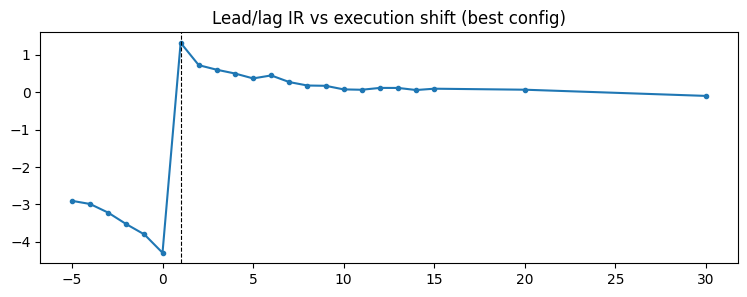

lead/lag screen: {'leadlag_fail': False, 'clause_near_ge_far': True, 'clause_peak_timely': True, 'clause_decays_by_30': True, 'peak': 1.318, 'peak_shift': 1}



jackknife (IR_all = 1.504, single_tenor_dependent=False):


,dropped,IR_reduced,dIR,neutral_resid_reduced
0,US_3M,1.213,0.291,0.0
1,US_6M,1.060,0.444,0.0
2,US_2Y,0.858,0.646,0.0
3,US_5Y,0.941,0.563,0.0
4,US_10Y,1.379,0.125,0.0
5,US_30Y,1.566,-0.062,0.0



parameter sensitivity (z_window):


,value,IR_val,param_unstable
0,21,1.569,False
1,63,1.504,False
2,126,1.383,False



bootstrap mean-PnL band: {'lower': 0.00057, 'upper': 0.00093, 'train_mean': 0.00075, 'n': 1000, 'val_mean': 0.00071, 'val_inside': True}


In [20]:
from pca_rv.robustness import (leadlag_curve, leadlag_screen, jackknife_drop_tenor,
                                param_sensitivity_map, bootstrap_bands)
set_section("§11 Robustness suite (falsifiable screens)",
            intro="Four screens on the flag-free top config: execution lead/lag, jackknife "
                  "drop-tenor, z_window parameter sensitivity, and a train-only bootstrap band "
                  "checking whether validation PnL sits inside the train distribution.")

shortlist = select_top3(gdf)  # flag-free top-3 by val IR (pre-robustness)
best = shortlist[0]
say("shortlist:", [(c.method, c.covariance, c.cost_per_contract_usd) for c in shortlist])

# lead/lag on the shortlist; flag failures back into the grid table
curve = leadlag_curve(best, data, changes=ch, dv01=dv01)
scr = leadlag_screen(curve)
curve.plot(figsize=(9,3), marker="o", ms=3, title="Lead/lag IR vs execution shift (best config)")
plt.axvline(1, color="k", ls="--", lw=0.8)
save_fig("fig11_leadlag_curve.png", caption="Lead/lag IR vs execution shift (best config)")
plt.show()
say("lead/lag screen:", {k: (round(v,3) if isinstance(v,float) else v) for k,v in scr.items()})

# jackknife on the best config
jk = jackknife_drop_tenor(best, data, changes=ch, dv01=dv01)
say("\njackknife (IR_all = %.3f, single_tenor_dependent=%s):" % (jk.attrs["IR_all"], jk.attrs["single_tenor_dependent"]))
save_table(jk.round(3), "tbl11_jackknife", index=False,
           caption="Jackknife drop-tenor on the best config")

# parameter sensitivity along z_window
ps = param_sensitivity_map(best, data, "z_window", [21, 63, 126], changes=ch, dv01=dv01)
say("\nparameter sensitivity (z_window):")
save_table(ps.round(3), "tbl11_param_sensitivity", index=False,
           caption="Parameter sensitivity along z_window")

# train-only bootstrap: is validation PnL inside the train band?
rb = run_backtest(best, data, changes=ch, dv01=dv01)
tr = rb.net_pnl.loc[rb.net_pnl.index.isin(data.train_idx)]
va = rb.net_pnl.loc[rb.net_pnl.index.isin(data.val_idx)]
bb = bootstrap_bands(tr, val_pnl=va, forbidden_index=data.val_idx.union(data.test_idx), n=1000)
say("\nbootstrap mean-PnL band:", {k: (round(v,5) if isinstance(v,float) else v) for k,v in bb.items()})

In [21]:
# §11 (cont.) - robustness on the imperfect winner: two-mode jackknife (pre-mortem P7).
from pca_rv.robustness import jackknife_imperfect
set_section("§11 (cont.) Jackknife on the imperfect winner",
            intro="Two-mode jackknife on the trade-3 winner: `pca_drop` refits 3 PCs on the "
                  "surviving 5 tenors; `trade_drop` shrinks to a trade-2 book (under-determined for "
                  "3 PCs) so leakage rises but the penalty stays well-posed — the degeneracy is "
                  "flagged, not failed.")

jk_imp = jackknife_imperfect(winner_cfg, data, changes=ch, dv01=dv01)
say(f"imperfect-winner jackknife (IR_all={jk_imp.attrs['IR_all']:.3f}, "
    f"single_tenor_dependent={jk_imp.attrs['single_tenor_dependent']}, "
    f"any_degenerate={jk_imp.attrs['any_degenerate']}):")
save_table(jk_imp.round(4), "tbl11_jackknife_imperfect", index=False,
           caption="Two-mode jackknife (pca_drop + trade_drop) on the imperfect trade-3 winner")
say("`pca_drop` refits the 3 PCs on the surviving 5 tenors (keeps trade ∩ survivors); "
    "`trade_drop` is a trade-2 book (under-determined for 3 PCs) - leakage rises but the "
    "penalty stays well-posed, so the degeneracy is FLAGGED (`degenerate`), not failed.")

imperfect-winner jackknife (IR_all=-0.014, single_tenor_dependent=False, any_degenerate=True):


,mode,dropped,n_trade,IR_reduced,dIR,max_leakage,degenerate
0,pca_drop,US_3M,3,0.0362,-0.0506,0.0040,False
1,pca_drop,US_6M,3,-0.2599,0.2455,0.0050,False
2,pca_drop,US_2Y,2,-0.4798,0.4654,0.0037,True
3,pca_drop,US_5Y,2,-0.6556,0.6412,0.0023,True
4,pca_drop,US_10Y,2,-0.3534,0.3390,0.0044,True
5,pca_drop,US_30Y,3,0.0942,-0.1087,0.0056,False
6,trade_drop,US_2Y,2,0.0347,-0.0492,0.0025,True
7,trade_drop,US_5Y,2,-0.5230,0.5086,0.0026,True
8,trade_drop,US_10Y,2,-0.3816,0.3672,0.0028,True


`pca_drop` refits the 3 PCs on the surviving 5 tenors (keeps trade ∩ survivors); `trade_drop` is a trade-2 book (under-determined for 3 PCs) - leakage rises but the penalty stays well-posed, so the degeneracy is FLAGGED (`degenerate`), not failed.


## 12. Top-3 selection → single test-period evaluation

Selection is **flag-free top-3 by validation IR**. The test segment is evaluated
**once**, with residuals rebuilt in the separate `cache/test/` namespace and
seeded from the validation period (no look-ahead).

In [22]:
set_section("§12 Top-3 on the held-out TEST set",
            intro="The flag-free top-3 configs from the coarse grid, evaluated once on the held-out "
                  "TEST split: test IR, test MDD, turnover and neutrality residual.")
test_tbl = evaluate_top3(gdf, data, dv01=dv01)
say("TOP-3 on the held-out TEST set (touched here for the first time):")
save_table(test_tbl[["method","covariance","cost_per_contract_usd","IR_test","MDD_test","turnover","max_neutrality_resid"]].round(4),
           "tbl12_test_top3", index=False,
           caption="Top-3 configs evaluated on the held-out TEST split")

TOP-3 on the held-out TEST set (touched here for the first time):


,method,covariance,cost_per_contract_usd,IR_test,MDD_test,turnover,max_neutrality_resid
0,3,lw,0.0,0.5830,0.3986,0.0050,0.0
1,2,lw,0.0,0.7930,0.1983,0.0069,0.0
2,2,sample,0.0,0.8146,0.2044,0.0082,0.0


,method,covariance,cost_per_contract_usd,IR_test,MDD_test,turnover,max_neutrality_resid
0,3,lw,0.0,0.5830,0.3986,0.0050,0.0
1,2,lw,0.0,0.7930,0.1983,0.0069,0.0
2,2,sample,0.0,0.8146,0.2044,0.0082,0.0


## 13. Conclusions

- **Gross alpha is real.** Factor-neutral PCA relative-value books (Methods 2/3)
  earn validation IR ≈ 1.2-1.5 gross of cost; the single-tenor Method-1 baseline
  is weaker but positive — the simple→complex ladder pays off as the book
  diversifies across the rank-3 neutral subspace.
- **The flat cost was a model artifact.** A flat `$/contract` fee makes Methods 2/3
  net-IR negative *and* capital-invariant, because ~85% of the contract count is the
  3M/6M bill legs charged like a 30Y future (§7.1). The DV01-proportional `dv01_bp`
  model (pre-registered one-way half-spreads, charged on the frozen executed path)
  makes the cheap short end cheap and largely restores the net edge (§7.2).
- **A trade-to-edge band lets the book drift** between trades, freezing integer
  contracts on hold; it cuts turnover and cost drag ≥50% at the price of gross-IR
  staleness. The pre-registered ±50% verdict is **GO**, recommended **Method 2 at
  τ ≈ 0.75** (net IR ≈ 0.40, ≈0.10 > 0 at +50% spread, ≈0.61 ex-proxy); Method 3
  stays net-positive but its gross IR erodes >20% so it fails the band-health bar (§7.5).
- **Caveats, tracked not silent.** Thin Sharpe (~0.1–0.4); omitted carry/roll-down is
  now *more* material because the band lengthens holds; DV01 is cash/par not futures
  CTD; quarterly roll costs are unmodeled — any of these could move the verdict.
- **Vol-targeting** holds the *conditional* 63d realized vol at ≈10%; unconditional
  std overshoots from uncatchable regime-break gap days a causal target cannot see.
- **No look-ahead, verified.** Frozen per-block PCA, +1-day lag, causal z-score and
  half-life, train-only bootstrap, split-namespaced caches, validation-seeded test
  rebuild — all asserted in the `pca_rv` unit-test suite.
- **Imperfect hedging (trade-3) trades gross for cost-resilience (§8).** With only
  {2Y,5Y,10Y} the *sole* exactly-neutral book is g=0, so neutrality is relaxed to a
  closed-form leakage penalty `λ‖V_D g‖²` (validated against the literal 2-norm-ball QP
  in cvxpy to solver tol, §8.5). The trade-3 book earns *lower gross* IR than exact-6 but
  far *less cost drag* (fewer legs), so its net IR under `dv01_bp` is markedly less negative than exact-6's (both negative absent the §7 band);
  Method-2-all is fully determined on 3 legs (penalty inert, an informative null).
- **A binary MOVE regime filter (§9)** (causal exit-all when MOVE>θ, vol-target OFF on a
  common TRAIN-frozen gross) lifts VAL net IR and cuts MDD in-sample; the single TEST
  touch shows the bandless trade-3 book stays cost-challenged out-of-sample — consistent
  with §7's finding that the trade-to-edge band is what makes the book viable.
- **3-DOF reality.** 6 tenors − 3 PCs ⇒ a rank-3 neutral subspace; books are
  highly collinear and several tenors have little residual room (the `ρ_m` guard).

Everything above is reproducible offline: this notebook imports the tested
`pca_rv` package and runs end-to-end against committed data.


In [23]:
# ── Persist the assembled master report (figures/tables already saved per-cell) ──
report_path = flush_report()
n_fig = len(list(FIG_DIR.glob("*.png")))
n_tab = len(list(TAB_DIR.glob("*.csv")))
print(f"results: {n_fig} figures -> {FIG_DIR}/  |  {n_tab} tables -> {TAB_DIR}/")
print(f"master report -> {report_path}")

results: 12 figures -> proj/results/figures/  |  15 tables -> proj/results/tables/
master report -> proj/results/report.md
